🚀 ANALISADOR DE DIFRATOGRAMA XRD
✓ Dados carregados: 4501 pontos
✓ Faixa angular: 10.00° - 100.00°
✓ Intensidade máxima: 4121
✓ Amostra: Ti-50Nb-12Mo

=== PICOS DETECTADOS (5) ===
Pico 1: 2θ = 39.14°, Intensidade = 4121
Pico 2: 2θ = 56.52°, Intensidade = 550
Pico 3: 2θ = 70.72°, Intensidade = 903
Pico 4: 2θ = 83.94°, Intensidade = 320
Pico 5: 2θ = 96.62°, Intensidade = 364

=== VALORES TEÓRICOS ===
Plano (1, 0, 1): 2θ = 38.64°
Plano (2, 0, 0): 2θ = 55.79°
Plano (2, 1, 1): 2θ = 69.92°
Plano (2, 2, 0): 2θ = 82.86°
Plano (3, 1, 0): 2θ = 95.43°

=== ASSOCIAÇÃO DE PICOS ===

Procurando plano (1, 0, 1) (teórico: 38.64°)
  Pico 1 (39.14°): diferença = 0.500°
  Pico 2 (56.52°): diferença = 17.880°
  Pico 3 (70.72°): diferença = 32.080°
  Pico 4 (83.94°): diferença = 45.300°
  Pico 5 (96.62°): diferença = 57.980°
  ✓ ASSOCIADO: 39.14° (Δ = 0.500°)

Procurando plano (2, 0, 0) (teórico: 55.79°)
  Pico 2 (56.52°): diferença = 0.727°
  Pico 3 (70.72°): diferença = 14.927°
  Pico 4 (83.94°): diferen

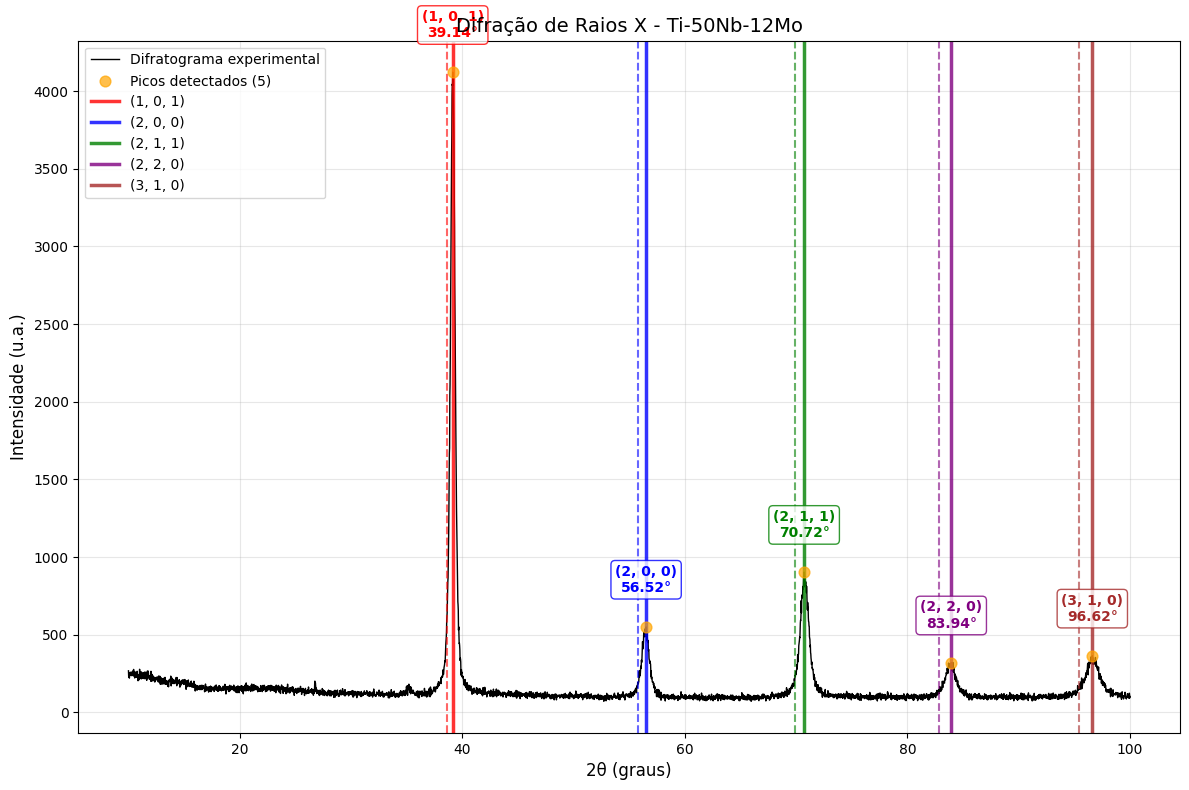


📋 RELATÓRIO FINAL
Picos identificados (experimental vs teórico):
Plano (1, 0, 1): Teórico = 38.64°, Experimental = 39.14°, Intensidade = 4121
Plano (2, 0, 0): Teórico = 55.79°, Experimental = 56.52°, Intensidade = 550
Plano (2, 1, 1): Teórico = 69.92°, Experimental = 70.72°, Intensidade = 903
Plano (2, 2, 0): Teórico = 82.86°, Experimental = 83.94°, Intensidade = 320
Plano (3, 1, 0): Teórico = 95.43°, Experimental = 96.62°, Intensidade = 364

✅ Análise concluída! 5/5 planos identificados

🎉 Análise executada com sucesso!
📊 Para usar os resultados:
   - angles: ângulos 2θ
   - intensity: intensidades
   - matched_peaks: picos identificados
   - all_peaks: todos os picos detectados


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks

# Constantes
lambda_cu = 1.544  # comprimento de onda Cu Kα
a = 3.30  # parâmetro de rede aproximado
hkl_planes = [(1,0,1), (2,0,0), (2,1,1), (2,2,0), (3,1,0)]

def processar_dados_difratometro(texto):
    """Processa dados do difratômetro no formato específico"""
    linhas = texto.strip().split('\n')
    angulos = []
    intensidades = []
    metadados = {}
    dados_numericos = False

    for linha in linhas:
        linha = linha.strip()
        if not linha:
            continue

        # Tentar processar como dados numéricos (ângulo\tintensidade)
        if '\t' in linha:
            partes = linha.split('\t')
            if len(partes) == 2:
                try:
                    angulo = float(partes[0])
                    intensidade = float(partes[1])
                    # Verificar se é um ângulo válido
                    if 5 <= angulo <= 150:
                        angulos.append(angulo)
                        intensidades.append(intensidade)
                        dados_numericos = True
                        continue
                except ValueError:
                    pass

        # Se não é dado numérico, tratar como metadado
        if not dados_numericos:
            if '\t' in linha:
                partes = linha.split('\t', 1)
                metadados[partes[0]] = partes[1] if len(partes) > 1 else ""

    return np.array(angulos), np.array(intensidades), metadados

def two_theta(hkl, a, wavelength):
    """Calcula 2θ teórico para um plano hkl"""
    h, k, l = hkl
    d = a / np.sqrt(h**2 + k**2 + l**2)
    theta = np.arcsin(wavelength / (2*d))
    return np.degrees(2*theta)

def detectar_picos_melhorado(angles, intensity):
    """Detecta TODOS os picos relevantes"""
    max_int = np.max(intensity)
    mean_int = np.mean(intensity)
    std_int = np.std(intensity)

    # Múltiplas estratégias de detecção
    all_peaks = []

    # 1. Picos principais (alta intensidade)
    peaks1, _ = find_peaks(intensity,
                          height=max_int*0.1,
                          distance=20,
                          prominence=max_int*0.05)
    all_peaks.extend(peaks1)

    # 2. Picos secundários
    peaks2, _ = find_peaks(intensity,
                          height=max_int*0.05,
                          distance=15,
                          prominence=max_int*0.02)
    all_peaks.extend(peaks2)

    # 3. Picos menores
    peaks3, _ = find_peaks(intensity,
                          height=mean_int + 2*std_int,
                          distance=10,
                          prominence=max_int*0.01)
    all_peaks.extend(peaks3)

    # 4. Busca específica em regiões esperadas
    teoricos_aproximados = [39, 56, 70, 83, 95]  # Baseado na imagem
    for teo in teoricos_aproximados:
        # Buscar picos numa janela de ±3° ao redor dos valores esperados
        mask = (angles >= teo-3) & (angles <= teo+3)
        if np.any(mask):
            indices_regiao = np.where(mask)[0]
            intensidades_regiao = intensity[indices_regiao]
            if len(intensidades_regiao) > 0:
                idx_max = indices_regiao[np.argmax(intensidades_regiao)]
                all_peaks.append(idx_max)

    # Remover duplicatas e filtrar
    all_peaks = np.unique(all_peaks)

    # Filtrar picos muito próximos (manter o de maior intensidade)
    peaks_finais = []
    for peak in sorted(all_peaks):
        adicionar = True
        for i, existing in enumerate(peaks_finais):
            if abs(angles[peak] - angles[existing]) < 2.0:  # Menos de 2°
                if intensity[peak] > intensity[existing]:
                    peaks_finais[i] = peak
                adicionar = False
                break
        if adicionar:
            peaks_finais.append(peak)

    return np.array(sorted(peaks_finais))

def associar_picos_sem_duplicacao(angles, intensity, hkl_planes, a, lambda_cu):
    """Associa picos sem permitir duplicação"""

    # Detectar picos
    peaks = detectar_picos_melhorado(angles, intensity)

    print(f"\n=== PICOS DETECTADOS ({len(peaks)}) ===")
    for i, p in enumerate(peaks):
        print(f"Pico {i+1}: 2θ = {angles[p]:.2f}°, Intensidade = {intensity[p]:.0f}")

    # Calcular valores teóricos
    print(f"\n=== VALORES TEÓRICOS ===")
    teoricos = []
    for hkl in hkl_planes:
        tth = two_theta(hkl, a, lambda_cu)
        teoricos.append((hkl, tth))
        print(f"Plano {hkl}: 2θ = {tth:.2f}°")

    # Ordenar por ângulo teórico
    teoricos.sort(key=lambda x: x[1])

    # Associação rigorosa
    matched_peaks = {}
    picos_usados = set()

    print(f"\n=== ASSOCIAÇÃO DE PICOS ===")

    for hkl, tth_teorico in teoricos:
        melhor_pico = None
        menor_diferenca = float('inf')

        print(f"\nProcurando plano {hkl} (teórico: {tth_teorico:.2f}°)")

        # Buscar melhor match entre picos não usados
        for i, peak_idx in enumerate(peaks):
            if peak_idx in picos_usados:
                continue

            diferenca = abs(angles[peak_idx] - tth_teorico)
            print(f"  Pico {i+1} ({angles[peak_idx]:.2f}°): diferença = {diferenca:.3f}°")

            if diferenca < 3.0 and diferenca < menor_diferenca:  # Tolerância de 3°
                melhor_pico = peak_idx
                menor_diferenca = diferenca

        if melhor_pico is not None:
            matched_peaks[hkl] = {
                'teorico': tth_teorico,
                'experimental': angles[melhor_pico],
                'intensidade': intensity[melhor_pico],
                'diferenca': menor_diferenca
            }
            picos_usados.add(melhor_pico)
            print(f"  ✓ ASSOCIADO: {angles[melhor_pico]:.2f}° (Δ = {menor_diferenca:.3f}°)")
        else:
            print(f"  ✗ NÃO ENCONTRADO")

    return matched_peaks, peaks

def plotar_resultado(angles, intensity, matched_peaks, metadados, all_peaks):
    """Plotar resultado"""

    plt.figure(figsize=(12, 8))

    # Plot do difratograma
    plt.plot(angles, intensity, 'k-', linewidth=1, label="Difratograma experimental")

    # Marcar todos os picos detectados
    plt.scatter(angles[all_peaks], intensity[all_peaks],
               c='orange', s=60, alpha=0.7, zorder=5,
               label=f"Picos detectados ({len(all_peaks)})")

    # Cores para cada plano
    cores = ['red', 'blue', 'green', 'purple', 'brown']

    # Marcar picos identificados
    for i, (hkl, dados) in enumerate(matched_peaks.items()):
        cor = cores[i % len(cores)]

        # Linha experimental (sólida)
        plt.axvline(dados['experimental'], color=cor, linestyle='-',
                   linewidth=2.5, alpha=0.8, label=f"{hkl}")

        # Linha teórica (tracejada)
        plt.axvline(dados['teorico'], color=cor, linestyle='--',
                   linewidth=1.5, alpha=0.6)

        # Anotação
        y_pos = dados['intensidade'] + np.max(intensity) * 0.05
        plt.text(dados['experimental'], y_pos, f"{hkl}\n{dados['experimental']:.2f}°",
                ha='center', va='bottom', fontsize=10, color=cor, weight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white',
                         edgecolor=cor, alpha=0.8))

    plt.xlabel("2θ (graus)", fontsize=12)
    plt.ylabel("Intensidade (u.a.)", fontsize=12)
    plt.title(f"Difração de Raios X - {metadados.get('Sample', 'Ti-50Nb-12Mo')}", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def analisar_difratograma_completo(dados_texto):
    """Função principal - EXECUTÁVEL"""

    print("🚀 ANALISADOR DE DIFRATOGRAMA XRD")
    print("="*60)

    # Processar dados
    angles, intensity, metadados = processar_dados_difratometro(dados_texto)

    if len(angles) == 0:
        print("❌ ERRO: Nenhum dado encontrado!")
        print("Verifique se os dados estão no formato correto.")
        return None

    print(f"✓ Dados carregados: {len(angles)} pontos")
    print(f"✓ Faixa angular: {angles.min():.2f}° - {angles.max():.2f}°")
    print(f"✓ Intensidade máxima: {intensity.max():.0f}")
    if 'Sample' in metadados:
        print(f"✓ Amostra: {metadados['Sample']}")

    # Associar picos
    matched_peaks, all_peaks = associar_picos_sem_duplicacao(
        angles, intensity, hkl_planes, a, lambda_cu)

    # Plotar resultado
    plotar_resultado(angles, intensity, matched_peaks, metadados, all_peaks)

    # Relatório final
    print("\n" + "="*80)
    print("📋 RELATÓRIO FINAL")
    print("="*80)

    print("Picos identificados (experimental vs teórico):")
    for hkl, dados in matched_peaks.items():
        print(f"Plano {hkl}: Teórico = {dados['teorico']:.2f}°, "
              f"Experimental = {dados['experimental']:.2f}°, "
              f"Intensidade = {dados['intensidade']:.0f}")

    print(f"\n✅ Análise concluída! {len(matched_peaks)}/{len(hkl_planes)} planos identificados")

    return angles, intensity, matched_peaks, all_peaks

# =============================================================================
# DADOS DE EXEMPLO - SUBSTITUA PELOS SEUS DADOS COMPLETOS
# =============================================================================

dados_completos = """
Sample	Ti-50Nb-12Mo
Comments	cond. pó
Filename	C:\Windmax\Data\MARCIO\JOSROB~1\rx24-08-2015\Ti-50Nb-12Mo.raw
Goniometer	Ultima+ theta-theta goniometer
Attachment	Standard sample holder
ScanningMode	2Theta/Theta
ScanningType	FT
X-Ray	40kV/20mA
DivSlit	1deg.
DivH.L.Slit	10mm
SctSlit	1deg.
RecSlit	0.3mm
K-beta filter
Start	10
Stop	100
Step	0.02
Offset	0
10	267
10.02	226
10.04	249
10.06	240
10.08	220
10.1	233
10.12	256
10.14	239
10.16	247
10.18	258
10.2	249
10.22	251
10.24	244
10.26	236
10.28	259
10.3	239
10.32	245
10.34	251
10.36	237
10.38	266
10.4	242
10.42	248
10.44	234
10.46	276
10.48	256
10.5	244
10.52	247
10.54	233
10.56	221
10.58	234
10.6	260
10.62	246
10.64	230
10.66	226
10.68	247
10.7	240
10.72	253
10.74	226
10.76	236
10.78	264
10.8	240
10.82	234
10.84	234
10.86	203
10.88	243
10.9	230
10.92	207
10.94	234
10.96	244
10.98	223
11	277
11.02	215
11.04	224
11.06	229
11.08	237
11.1	262
11.12	242
11.14	256
11.16	241
11.18	215
11.2	257
11.22	237
11.24	234
11.26	246
11.28	245
11.3	219
11.32	218
11.34	228
11.36	256
11.38	240
11.4	250
11.42	216
11.44	242
11.46	219
11.48	260
11.5	239
11.52	231
11.54	216
11.56	230
11.58	222
11.6	253
11.62	226
11.64	206
11.66	230
11.68	248
11.7	266
11.72	241
11.74	223
11.76	232
11.78	265
11.8	243
11.82	235
11.84	234
11.86	219
11.88	213
11.9	235
11.92	228
11.94	216
11.96	230
11.98	215
12	201
12.02	264
12.04	201
12.06	231
12.08	227
12.1	200
12.12	244
12.14	210
12.16	222
12.18	223
12.2	213
12.22	216
12.24	233
12.26	220
12.28	224
12.3	202
12.32	224
12.34	221
12.36	195
12.38	216
12.4	198
12.42	222
12.44	213
12.46	212
12.48	208
12.5	225
12.52	223
12.54	224
12.56	221
12.58	224
12.6	227
12.62	203
12.64	225
12.66	216
12.68	196
12.7	195
12.72	234
12.74	201
12.76	219
12.78	228
12.8	194
12.82	232
12.84	224
12.86	181
12.88	222
12.9	213
12.92	182
12.94	191
12.96	221
12.98	210
13	217
13.02	181
13.04	187
13.06	189
13.08	190
13.1	215
13.12	194
13.14	207
13.16	185
13.18	207
13.2	182
13.22	222
13.24	189
13.26	198
13.28	225
13.3	189
13.32	182
13.34	189
13.36	180
13.38	205
13.4	179
13.42	204
13.44	203
13.46	197
13.48	194
13.5	179
13.52	187
13.54	168
13.56	200
13.58	199
13.6	164
13.62	191
13.64	203
13.66	197
13.68	212
13.7	206
13.72	199
13.74	201
13.76	199
13.78	206
13.8	233
13.82	224
13.84	170
13.86	200
13.88	208
13.9	184
13.92	215
13.94	219
13.96	195
13.98	203
14	195
14.02	197
14.04	185
14.06	211
14.08	186
14.1	199
14.12	192
14.14	202
14.16	185
14.18	198
14.2	195
14.22	194
14.24	199
14.26	218
14.28	224
14.3	220
14.32	186
14.34	171
14.36	224
14.38	197
14.4	185
14.42	181
14.44	189
14.46	187
14.48	204
14.5	189
14.52	197
14.54	196
14.56	210
14.58	205
14.6	181
14.62	162
14.64	192
14.66	188
14.68	192
14.7	196
14.72	175
14.74	202
14.76	181
14.78	193
14.8	195
14.82	207
14.84	191
14.86	189
14.88	208
14.9	187
14.92	184
14.94	183
14.96	204
14.98	179
15	210
15.02	198
15.04	185
15.06	211
15.08	203
15.1	205
15.12	201
15.14	183
15.16	177
15.18	148
15.2	195
15.22	192
15.24	203
15.26	182
15.28	171
15.3	200
15.32	165
15.34	189
15.36	174
15.38	208
15.4	172
15.42	182
15.44	185
15.46	176
15.48	180
15.5	166
15.52	176
15.54	167
15.56	193
15.58	191
15.6	174
15.62	189
15.64	201
15.66	179
15.68	176
15.7	174
15.72	161
15.74	176
15.76	177
15.78	187
15.8	175
15.82	179
15.84	183
15.86	160
15.88	200
15.9	179
15.92	178
15.94	166
15.96	167
15.98	180
16	137
16.02	170
16.04	176
16.06	167
16.08	161
16.1	164
16.12	167
16.14	170
16.16	142
16.18	172
16.2	159
16.22	149
16.24	170
16.26	150
16.28	164
16.3	156
16.32	162
16.34	167
16.36	148
16.38	146
16.4	149
16.42	163
16.44	173
16.46	161
16.48	150
16.5	169
16.52	145
16.54	158
16.56	151
16.58	154
16.6	175
16.62	150
16.64	147
16.66	164
16.68	158
16.7	155
16.72	167
16.74	168
16.76	172
16.78	154
16.8	159
16.82	150
16.84	132
16.86	141
16.88	147
16.9	141
16.92	182
16.94	166
16.96	137
16.98	161
17	160
17.02	147
17.04	165
17.06	157
17.08	156
17.1	143
17.12	150
17.14	152
17.16	152
17.18	162
17.2	130
17.22	147
17.24	145
17.26	164
17.28	144
17.3	138
17.32	159
17.34	153
17.36	165
17.38	169
17.4	150
17.42	133
17.44	165
17.46	154
17.48	146
17.5	163
17.52	149
17.54	143
17.56	149
17.58	150
17.6	157
17.62	152
17.64	162
17.66	152
17.68	151
17.7	134
17.72	142
17.74	146
17.76	169
17.78	146
17.8	167
17.82	150
17.84	163
17.86	151
17.88	176
17.9	141
17.92	145
17.94	159
17.96	164
17.98	157
18	138
18.02	160
18.04	152
18.06	135
18.08	150
18.1	154
18.12	161
18.14	172
18.16	165
18.18	145
18.2	140
18.22	167
18.24	150
18.26	155
18.28	147
18.3	153
18.32	157
18.34	142
18.36	138
18.38	154
18.4	154
18.42	153
18.44	149
18.46	157
18.48	141
18.5	167
18.52	168
18.54	142
18.56	160
18.58	143
18.6	150
18.62	148
18.64	152
18.66	180
18.68	166
18.7	175
18.72	141
18.74	151
18.76	118
18.78	150
18.8	165
18.82	165
18.84	145
18.86	145
18.88	151
18.9	149
18.92	164
18.94	154
18.96	166
18.98	167
19	134
19.02	151
19.04	144
19.06	134
19.08	135
19.1	174
19.12	159
19.14	140
19.16	153
19.18	157
19.2	145
19.22	165
19.24	163
19.26	169
19.28	150
19.3	148
19.32	164
19.34	146
19.36	150
19.38	163
19.4	161
19.42	153
19.44	151
19.46	175
19.48	155
19.5	138
19.52	161
19.54	149
19.56	143
19.58	137
19.6	150
19.62	156
19.64	148
19.66	129
19.68	165
19.7	141
19.72	137
19.74	150
19.76	126
19.78	166
19.8	151
19.82	148
19.84	170
19.86	149
19.88	155
19.9	156
19.92	141
19.94	126
19.96	158
19.98	165
20	144
20.02	147
20.04	146
20.06	146
20.08	151
20.1	149
20.12	170
20.14	140
20.16	170
20.18	136
20.2	164
20.22	152
20.24	168
20.26	132
20.28	160
20.3	134
20.32	119
20.34	161
20.36	142
20.38	143
20.4	166
20.42	160
20.44	139
20.46	167
20.48	176
20.5	164
20.52	149
20.54	150
20.56	137
20.58	189
20.6	166
20.62	149
20.64	151
20.66	166
20.68	149
20.7	161
20.72	173
20.74	141
20.76	146
20.78	139
20.8	162
20.82	149
20.84	151
20.86	166
20.88	144
20.9	159
20.92	148
20.94	154
20.96	149
20.98	134
21	152
21.02	161
21.04	176
21.06	158
21.08	182
21.1	145
21.12	139
21.14	166
21.16	148
21.18	138
21.2	166
21.22	142
21.24	169
21.26	178
21.28	179
21.3	164
21.32	165
21.34	143
21.36	154
21.38	154
21.4	171
21.42	148
21.44	163
21.46	153
21.48	153
21.5	161
21.52	169
21.54	144
21.56	155
21.58	156
21.6	162
21.62	132
21.64	163
21.66	157
21.68	149
21.7	136
21.72	144
21.74	145
21.76	139
21.78	153
21.8	138
21.82	153
21.84	141
21.86	135
21.88	172
21.9	162
21.92	153
21.94	142
21.96	143
21.98	163
22	168
22.02	133
22.04	158
22.06	150
22.08	173
22.1	141
22.12	162
22.14	150
22.16	145
22.18	157
22.2	174
22.22	172
22.24	148
22.26	163
22.28	156
22.3	145
22.32	133
22.34	152
22.36	150
22.38	145
22.4	165
22.42	135
22.44	148
22.46	162
22.48	149
22.5	157
22.52	142
22.54	171
22.56	162
22.58	165
22.6	150
22.62	169
22.64	153
22.66	147
22.68	170
22.7	159
22.72	150
22.74	144
22.76	136
22.78	138
22.8	174
22.82	146
22.84	169
22.86	161
22.88	147
22.9	170
22.92	142
22.94	149
22.96	143
22.98	166
23	163
23.02	152
23.04	153
23.06	153
23.08	164
23.1	135
23.12	148
23.14	162
23.16	144
23.18	149
23.2	160
23.22	140
23.24	126
23.26	152
23.28	175
23.3	144
23.32	145
23.34	145
23.36	169
23.38	158
23.4	144
23.42	149
23.44	157
23.46	167
23.48	173
23.5	165
23.52	154
23.54	130
23.56	146
23.58	162
23.6	159
23.62	160
23.64	162
23.66	121
23.68	153
23.7	147
23.72	147
23.74	166
23.76	176
23.78	167
23.8	150
23.82	157
23.84	157
23.86	143
23.88	161
23.9	122
23.92	164
23.94	163
23.96	146
23.98	141
24	141
24.02	152
24.04	138
24.06	144
24.08	159
24.1	132
24.12	144
24.14	148
24.16	119
24.18	141
24.2	142
24.22	124
24.24	137
24.26	163
24.28	152
24.3	181
24.32	152
24.34	147
24.36	133
24.38	137
24.4	135
24.42	150
24.44	153
24.46	125
24.48	156
24.5	154
24.52	126
24.54	149
24.56	159
24.58	137
24.6	145
24.62	154
24.64	143
24.66	148
24.68	162
24.7	138
24.72	144
24.74	132
24.76	164
24.78	144
24.8	156
24.82	154
24.84	134
24.86	146
24.88	134
24.9	109
24.92	145
24.94	140
24.96	149
24.98	145
25	129
25.02	134
25.04	153
25.06	153
25.08	128
25.1	146
25.12	121
25.14	136
25.16	135
25.18	133
25.2	140
25.22	136
25.24	156
25.26	151
25.28	138
25.3	129
25.32	138
25.34	154
25.36	134
25.38	137
25.4	148
25.42	134
25.44	144
25.46	167
25.48	145
25.5	151
25.52	147
25.54	148
25.56	115
25.58	133
25.6	135
25.62	133
25.64	146
25.66	134
25.68	154
25.7	146
25.72	136
25.74	128
25.76	136
25.78	145
25.8	137
25.82	108
25.84	132
25.86	141
25.88	140
25.9	154
25.92	147
25.94	129
25.96	134
25.98	119
26	126
26.02	137
26.04	135
26.06	127
26.08	123
26.1	137
26.12	142
26.14	146
26.16	123
26.18	163
26.2	134
26.22	126
26.24	124
26.26	132
26.28	132
26.3	136
26.32	133
26.34	132
26.36	145
26.38	132
26.4	130
26.42	141
26.44	131
26.46	152
26.48	128
26.5	122
26.52	140
26.54	133
26.56	130
26.58	147
26.6	119
26.62	110
26.64	139
26.66	126
26.68	137
26.7	123
26.72	145
26.74	200
26.76	200
26.78	179
26.8	190
26.82	173
26.84	151
26.86	132
26.88	156
26.9	139
26.92	121
26.94	144
26.96	133
26.98	139
27	127
27.02	124
27.04	141
27.06	122
27.08	131
27.1	116
27.12	138
27.14	114
27.16	108
27.18	128
27.2	130
27.22	143
27.24	125
27.26	114
27.28	125
27.3	121
27.32	133
27.34	130
27.36	122
27.38	117
27.4	119
27.42	153
27.44	134
27.46	140
27.48	110
27.5	130
27.52	144
27.54	115
27.56	132
27.58	129
27.6	137
27.62	108
27.64	137
27.66	132
27.68	117
27.7	127
27.72	129
27.74	130
27.76	127
27.78	122
27.8	109
27.82	119
27.84	124
27.86	106
27.88	121
27.9	125
27.92	136
27.94	112
27.96	129
27.98	143
28	120
28.02	122
28.04	114
28.06	119
28.08	107
28.1	139
28.12	113
28.14	106
28.16	128
28.18	136
28.2	133
28.22	123
28.24	106
28.26	136
28.28	116
28.3	123
28.32	133
28.34	118
28.36	124
28.38	129
28.4	117
28.42	136
28.44	118
28.46	96
28.48	120
28.5	110
28.52	117
28.54	109
28.56	142
28.58	98
28.6	116
28.62	106
28.64	120
28.66	119
28.68	132
28.7	110
28.72	126
28.74	138
28.76	133
28.78	143
28.8	126
28.82	120
28.84	112
28.86	107
28.88	102
28.9	120
28.92	106
28.94	104
28.96	120
28.98	138
29	129
29.02	135
29.04	113
29.06	143
29.08	133
29.1	126
29.12	128
29.14	113
29.16	113
29.18	123
29.2	133
29.22	115
29.24	152
29.26	123
29.28	123
29.3	120
29.32	127
29.34	124
29.36	112
29.38	136
29.4	135
29.42	107
29.44	131
29.46	146
29.48	106
29.5	130
29.52	118
29.54	123
29.56	117
29.58	113
29.6	121
29.62	120
29.64	117
29.66	130
29.68	130
29.7	121
29.72	121
29.74	128
29.76	131
29.78	106
29.8	118
29.82	133
29.84	113
29.86	116
29.88	116
29.9	116
29.92	131
29.94	125
29.96	132
29.98	119
30	132
30.02	115
30.04	137
30.06	113
30.08	117
30.1	121
30.12	121
30.14	140
30.16	121
30.18	98
30.2	136
30.22	101
30.24	105
30.26	112
30.28	111
30.3	130
30.32	124
30.34	118
30.36	135
30.38	121
30.4	121
30.42	116
30.44	115
30.46	119
30.48	105
30.5	121
30.52	94
30.54	131
30.56	121
30.58	134
30.6	116
30.62	125
30.64	111
30.66	121
30.68	131
30.7	114
30.72	128
30.74	131
30.76	130
30.78	116
30.8	116
30.82	108
30.84	106
30.86	127
30.88	116
30.9	101
30.92	134
30.94	116
30.96	111
30.98	104
31	116
31.02	119
31.04	124
31.06	111
31.08	119
31.1	109
31.12	123
31.14	114
31.16	124
31.18	131
31.2	138
31.22	125
31.24	127
31.26	121
31.28	116
31.3	123
31.32	119
31.34	126
31.36	128
31.38	120
31.4	123
31.42	139
31.44	127
31.46	131
31.48	108
31.5	118
31.52	116
31.54	127
31.56	119
31.58	106
31.6	106
31.62	114
31.64	104
31.66	133
31.68	116
31.7	108
31.72	105
31.74	120
31.76	130
31.78	118
31.8	119
31.82	115
31.84	120
31.86	119
31.88	123
31.9	107
31.92	112
31.94	98
31.96	130
31.98	110
32	118
32.02	127
32.04	150
32.06	120
32.08	133
32.1	111
32.12	108
32.14	114
32.16	108
32.18	113
32.2	104
32.22	108
32.24	105
32.26	104
32.28	118
32.3	130
32.32	116
32.34	128
32.36	122
32.38	128
32.4	117
32.42	120
32.44	125
32.46	113
32.48	130
32.5	105
32.52	143
32.54	120
32.56	134
32.58	122
32.6	121
32.62	119
32.64	103
32.66	119
32.68	120
32.7	128
32.72	110
32.74	119
32.76	112
32.78	110
32.8	119
32.82	135
32.84	115
32.86	118
32.88	121
32.9	98
32.92	115
32.94	121
32.96	122
32.98	100
33	119
33.02	116
33.04	109
33.06	120
33.08	118
33.1	121
33.12	117
33.14	112
33.16	120
33.18	117
33.2	127
33.22	113
33.24	111
33.26	120
33.28	108
33.3	123
33.32	112
33.34	112
33.36	93
33.38	103
33.4	132
33.42	110
33.44	102
33.46	93
33.48	119
33.5	120
33.52	122
33.54	118
33.56	113
33.58	113
33.6	102
33.62	146
33.64	116
33.66	118
33.68	119
33.7	106
33.72	129
33.74	104
33.76	119
33.78	115
33.8	120
33.82	109
33.84	114
33.86	126
33.88	136
33.9	105
33.92	117
33.94	113
33.96	102
33.98	96
34	101
34.02	107
34.04	120
34.06	122
34.08	117
34.1	113
34.12	100
34.14	101
34.16	118
34.18	121
34.2	105
34.22	115
34.24	99
34.26	116
34.28	111
34.3	98
34.32	107
34.34	106
34.36	129
34.38	111
34.4	109
34.42	125
34.44	112
34.46	139
34.48	127
34.5	111
34.52	117
34.54	130
34.56	116
34.58	120
34.6	105
34.62	128
34.64	117
34.66	121
34.68	114
34.7	139
34.72	111
34.74	114
34.76	124
34.78	114
34.8	124
34.82	134
34.84	108
34.86	114
34.88	142
34.9	113
34.92	120
34.94	128
34.96	126
34.98	165
35	151
35.02	155
35.04	138
35.06	172
35.08	109
35.1	151
35.12	168
35.14	145
35.16	152
35.18	175
35.2	181
35.22	158
35.24	161
35.26	159
35.28	127
35.3	149
35.32	138
35.34	165
35.36	119
35.38	127
35.4	161
35.42	156
35.44	133
35.46	142
35.48	143
35.5	141
35.52	123
35.54	127
35.56	123
35.58	128
35.6	142
35.62	130
35.64	126
35.66	125
35.68	120
35.7	118
35.72	123
35.74	112
35.76	109
35.78	119
35.8	122
35.82	114
35.84	109
35.86	124
35.88	134
35.9	132
35.92	128
35.94	109
35.96	114
35.98	99
36	138
36.02	125
36.04	127
36.06	115
36.08	94
36.1	125
36.12	116
36.14	94
36.16	134
36.18	135
36.2	136
36.22	131
36.24	126
36.26	114
36.28	117
36.3	127
36.32	123
36.34	127
36.36	102
36.38	138
36.4	126
36.42	128
36.44	110
36.46	113
36.48	107
36.5	107
36.52	127
36.54	126
36.56	116
36.58	112
36.6	154
36.62	126
36.64	115
36.66	104
36.68	132
36.7	110
36.72	128
36.74	136
36.76	118
36.78	128
36.8	98
36.82	108
36.84	113
36.86	127
36.88	102
36.9	105
36.92	135
36.94	120
36.96	124
36.98	144
37	141
37.02	130
37.04	154
37.06	129
37.08	125
37.1	100
37.12	125
37.14	163
37.16	136
37.18	131
37.2	148
37.22	112
37.24	117
37.26	136
37.28	137
37.3	127
37.32	123
37.34	134
37.36	134
37.38	135
37.4	145
37.42	152
37.44	142
37.46	163
37.48	151
37.5	140
37.52	139
37.54	141
37.56	162
37.58	131
37.6	140
37.62	149
37.64	162
37.66	157
37.68	153
37.7	165
37.72	157
37.74	154
37.76	163
37.78	181
37.8	182
37.82	163
37.84	172
37.86	197
37.88	176
37.9	192
37.92	172
37.94	180
37.96	187
37.98	186
38	186
38.02	196
38.04	195
38.06	208
38.08	222
38.1	185
38.12	217
38.14	228
38.16	228
38.18	231
38.2	235
38.22	227
38.24	240
38.26	241
38.28	274
38.3	243
38.32	247
38.34	270
38.36	289
38.38	296
38.4	304
38.42	319
38.44	331
38.46	325
38.48	364
38.5	402
38.52	441
38.54	460
38.56	483
38.58	520
38.6	590
38.62	625
38.64	643
38.66	714
38.68	759
38.7	841
38.72	866
38.74	971
38.76	1075
38.78	1172
38.8	1363
38.82	1474
38.84	1669
38.86	1701
38.88	2037
38.9	2109
38.92	2278
38.94	2567
38.96	2732
38.98	2955
39	3208
39.02	3393
39.04	3590
39.06	3713
39.08	3970
39.1	4044
39.12	4034
39.14	4121
39.16	4074
39.18	3980
39.2	3923
39.22	3828
39.24	3719
39.26	3459
39.28	3322
39.3	3127
39.32	2766
39.34	2615
39.36	2431
39.38	2189
39.4	2045
39.42	1806
39.44	1622
39.46	1499
39.48	1314
39.5	1210
39.52	1117
39.54	1027
39.56	898
39.58	807
39.6	712
39.62	692
39.64	657
39.66	529
39.68	550
39.7	481
39.72	443
39.74	446
39.76	430
39.78	405
39.8	334
39.82	348
39.84	343
39.86	324
39.88	253
39.9	238
39.92	275
39.94	251
39.96	259
39.98	231
40	236
40.02	223
40.04	233
40.06	230
40.08	218
40.1	216
40.12	194
40.14	180
40.16	205
40.18	186
40.2	171
40.22	199
40.24	211
40.26	211
40.28	178
40.3	190
40.32	184
40.34	158
40.36	181
40.38	163
40.4	147
40.42	189
40.44	191
40.46	164
40.48	167
40.5	176
40.52	148
40.54	139
40.56	142
40.58	153
40.6	164
40.62	173
40.64	150
40.66	164
40.68	165
40.7	149
40.72	139
40.74	149
40.76	170
40.78	154
40.8	147
40.82	139
40.84	145
40.86	131
40.88	116
40.9	134
40.92	138
40.94	140
40.96	130
40.98	153
41	139
41.02	122
41.04	124
41.06	156
41.08	134
41.1	146
41.12	138
41.14	138
41.16	136
41.18	136
41.2	138
41.22	126
41.24	125
41.26	136
41.28	158
41.3	134
41.32	124
41.34	115
41.36	136
41.38	154
41.4	139
41.42	122
41.44	135
41.46	144
41.48	145
41.5	127
41.52	143
41.54	132
41.56	150
41.58	153
41.6	122
41.62	135
41.64	125
41.66	125
41.68	142
41.7	121
41.72	128
41.74	121
41.76	115
41.78	129
41.8	116
41.82	106
41.84	154
41.86	123
41.88	159
41.9	143
41.92	135
41.94	133
41.96	115
41.98	135
42	136
42.02	161
42.04	149
42.06	145
42.08	129
42.1	118
42.12	123
42.14	119
42.16	116
42.18	129
42.2	99
42.22	123
42.24	117
42.26	123
42.28	132
42.3	123
42.32	123
42.34	124
42.36	128
42.38	138
42.4	130
42.42	126
42.44	122
42.46	113
42.48	104
42.5	127
42.52	109
42.54	122
42.56	143
42.58	104
42.6	132
42.62	123
42.64	114
42.66	132
42.68	129
42.7	116
42.72	126
42.74	100
42.76	126
42.78	124
42.8	149
42.82	102
42.84	110
42.86	124
42.88	112
42.9	119
42.92	132
42.94	133
42.96	108
42.98	121
43	134
43.02	112
43.04	115
43.06	150
43.08	100
43.1	133
43.12	114
43.14	141
43.16	122
43.18	114
43.2	109
43.22	143
43.24	116
43.26	127
43.28	110
43.3	122
43.32	117
43.34	137
43.36	115
43.38	127
43.4	121
43.42	122
43.44	126
43.46	105
43.48	120
43.5	117
43.52	121
43.54	114
43.56	114
43.58	112
43.6	120
43.62	129
43.64	105
43.66	99
43.68	105
43.7	118
43.72	127
43.74	116
43.76	130
43.78	121
43.8	125
43.82	120
43.84	125
43.86	116
43.88	113
43.9	118
43.92	123
43.94	96
43.96	121
43.98	118
44	105
44.02	108
44.04	112
44.06	119
44.08	120
44.1	128
44.12	112
44.14	124
44.16	139
44.18	125
44.2	106
44.22	109
44.24	110
44.26	119
44.28	131
44.3	123
44.32	125
44.34	102
44.36	132
44.38	122
44.4	121
44.42	132
44.44	111
44.46	111
44.48	123
44.5	109
44.52	105
44.54	111
44.56	100
44.58	105
44.6	108
44.62	123
44.64	108
44.66	111
44.68	106
44.7	125
44.72	129
44.74	123
44.76	100
44.78	109
44.8	119
44.82	114
44.84	141
44.86	110
44.88	91
44.9	93
44.92	132
44.94	138
44.96	119
44.98	103
45	116
45.02	115
45.04	108
45.06	111
45.08	132
45.1	118
45.12	103
45.14	108
45.16	113
45.18	128
45.2	88
45.22	119
45.24	116
45.26	114
45.28	113
45.3	125
45.32	124
45.34	103
45.36	106
45.38	105
45.4	108
45.42	117
45.44	107
45.46	118
45.48	113
45.5	116
45.52	115
45.54	110
45.56	116
45.58	111
45.6	105
45.62	102
45.64	122
45.66	106
45.68	123
45.7	95
45.72	119
45.74	103
45.76	128
45.78	107
45.8	117
45.82	120
45.84	90
45.86	121
45.88	123
45.9	120
45.92	106
45.94	107
45.96	105
45.98	116
46	111
46.02	124
46.04	133
46.06	102
46.08	100
46.1	111
46.12	126
46.14	109
46.16	111
46.18	133
46.2	126
46.22	104
46.24	104
46.26	94
46.28	106
46.3	116
46.32	113
46.34	106
46.36	126
46.38	94
46.4	107
46.42	112
46.44	104
46.46	90
46.48	98
46.5	101
46.52	115
46.54	106
46.56	119
46.58	126
46.6	122
46.62	112
46.64	94
46.66	118
46.68	115
46.7	110
46.72	130
46.74	125
46.76	102
46.78	113
46.8	100
46.82	118
46.84	107
46.86	106
46.88	107
46.9	114
46.92	121
46.94	108
46.96	107
46.98	99
47	105
47.02	103
47.04	125
47.06	112
47.08	105
47.1	99
47.12	108
47.14	89
47.16	102
47.18	111
47.2	110
47.22	102
47.24	102
47.26	123
47.28	103
47.3	95
47.32	98
47.34	86
47.36	120
47.38	124
47.4	113
47.42	123
47.44	132
47.46	94
47.48	113
47.5	113
47.52	108
47.54	92
47.56	105
47.58	114
47.6	99
47.62	101
47.64	129
47.66	106
47.68	116
47.7	100
47.72	113
47.74	115
47.76	107
47.78	104
47.8	108
47.82	115
47.84	103
47.86	112
47.88	94
47.9	89
47.92	105
47.94	108
47.96	87
47.98	95
48	95
48.02	109
48.04	89
48.06	106
48.08	115
48.1	107
48.12	106
48.14	93
48.16	97
48.18	101
48.2	111
48.22	113
48.24	103
48.26	80
48.28	105
48.3	115
48.32	100
48.34	100
48.36	118
48.38	103
48.4	103
48.42	94
48.44	116
48.46	80
48.48	105
48.5	104
48.52	100
48.54	109
48.56	100
48.58	105
48.6	109
48.62	105
48.64	103
48.66	103
48.68	108
48.7	112
48.72	111
48.74	111
48.76	92
48.78	102
48.8	95
48.82	106
48.84	96
48.86	105
48.88	103
48.9	115
48.92	102
48.94	105
48.96	104
48.98	113
49	113
49.02	95
49.04	98
49.06	97
49.08	96
49.1	90
49.12	117
49.14	101
49.16	99
49.18	115
49.2	110
49.22	103
49.24	92
49.26	122
49.28	103
49.3	108
49.32	95
49.34	100
49.36	103
49.38	108
49.4	113
49.42	99
49.44	97
49.46	107
49.48	102
49.5	106
49.52	96
49.54	89
49.56	114
49.58	111
49.6	115
49.62	122
49.64	88
49.66	98
49.68	130
49.7	104
49.72	124
49.74	115
49.76	117
49.78	120
49.8	106
49.82	105
49.84	98
49.86	102
49.88	103
49.9	115
49.92	106
49.94	99
49.96	108
49.98	108
50	88
50.02	107
50.04	95
50.06	108
50.08	106
50.1	93
50.12	97
50.14	106
50.16	117
50.18	104
50.2	137
50.22	106
50.24	98
50.26	98
50.28	102
50.3	118
50.32	102
50.34	96
50.36	102
50.38	105
50.4	102
50.42	89
50.44	112
50.46	114
50.48	95
50.5	97
50.52	100
50.54	112
50.56	108
50.58	101
50.6	116
50.62	118
50.64	103
50.66	117
50.68	120
50.7	112
50.72	98
50.74	95
50.76	101
50.78	108
50.8	103
50.82	81
50.84	113
50.86	106
50.88	109
50.9	105
50.92	109
50.94	94
50.96	117
50.98	102
51	115
51.02	98
51.04	108
51.06	117
51.08	118
51.1	102
51.12	98
51.14	102
51.16	123
51.18	87
51.2	119
51.22	111
51.24	90
51.26	105
51.28	104
51.3	99
51.32	129
51.34	117
51.36	100
51.38	96
51.4	94
51.42	88
51.44	113
51.46	110
51.48	102
51.5	96
51.52	91
51.54	104
51.56	101
51.58	119
51.6	107
51.62	97
51.64	104
51.66	101
51.68	99
51.7	88
51.72	95
51.74	88
51.76	98
51.78	108
51.8	92
51.82	99
51.84	83
51.86	85
51.88	109
51.9	94
51.92	99
51.94	95
51.96	100
51.98	99
52	110
52.02	102
52.04	97
52.06	98
52.08	104
52.1	88
52.12	92
52.14	91
52.16	95
52.18	101
52.2	105
52.22	117
52.24	105
52.26	87
52.28	111
52.3	80
52.32	100
52.34	88
52.36	94
52.38	84
52.4	101
52.42	109
52.44	110
52.46	94
52.48	83
52.5	84
52.52	106
52.54	104
52.56	99
52.58	101
52.6	87
52.62	104
52.64	85
52.66	90
52.68	97
52.7	99
52.72	71
52.74	96
52.76	106
52.78	104
52.8	102
52.82	99
52.84	100
52.86	106
52.88	107
52.9	101
52.92	74
52.94	86
52.96	94
52.98	122
53	91
53.02	98
53.04	86
53.06	105
53.08	113
53.1	97
53.12	86
53.14	88
53.16	85
53.18	93
53.2	97
53.22	83
53.24	81
53.26	108
53.28	104
53.3	102
53.32	101
53.34	100
53.36	100
53.38	109
53.4	90
53.42	97
53.44	85
53.46	100
53.48	90
53.5	85
53.52	102
53.54	101
53.56	99
53.58	101
53.6	110
53.62	105
53.64	97
53.66	122
53.68	123
53.7	98
53.72	110
53.74	104
53.76	99
53.78	97
53.8	90
53.82	104
53.84	101
53.86	94
53.88	101
53.9	104
53.92	97
53.94	91
53.96	92
53.98	114
54	125
54.02	97
54.04	114
54.06	84
54.08	104
54.1	83
54.12	113
54.14	106
54.16	81
54.18	110
54.2	106
54.22	96
54.24	102
54.26	112
54.28	106
54.3	102
54.32	98
54.34	117
54.36	102
54.38	109
54.4	104
54.42	102
54.44	132
54.46	120
54.48	110
54.5	95
54.52	113
54.54	103
54.56	104
54.58	106
54.6	80
54.62	94
54.64	82
54.66	107
54.68	117
54.7	107
54.72	110
54.74	108
54.76	114
54.78	119
54.8	109
54.82	111
54.84	106
54.86	101
54.88	113
54.9	111
54.92	116
54.94	104
54.96	111
54.98	119
55	95
55.02	108
55.04	114
55.06	121
55.08	118
55.1	108
55.12	133
55.14	130
55.16	110
55.18	95
55.2	116
55.22	105
55.24	115
55.26	109
55.28	126
55.3	123
55.32	126
55.34	104
55.36	129
55.38	121
55.4	112
55.42	135
55.44	119
55.46	123
55.48	118
55.5	128
55.52	140
55.54	133
55.56	151
55.58	141
55.6	156
55.62	145
55.64	135
55.66	126
55.68	168
55.7	170
55.72	158
55.74	168
55.76	186
55.78	192
55.8	187
55.82	183
55.84	193
55.86	197
55.88	231
55.9	264
55.92	226
55.94	248
55.96	236
55.98	269
56	248
56.02	268
56.04	297
56.06	282
56.08	297
56.1	336
56.12	321
56.14	333
56.16	376
56.18	399
56.2	455
56.22	407
56.24	436
56.26	424
56.28	450
56.3	500
56.32	514
56.34	495
56.36	511
56.38	503
56.4	486
56.42	525
56.44	538
56.46	522
56.48	531
56.5	542
56.52	550
56.54	526
56.56	484
56.58	493
56.6	460
56.62	506
56.64	457
56.66	464
56.68	449
56.7	462
56.72	395
56.74	405
56.76	404
56.78	349
56.8	338
56.82	336
56.84	317
56.86	328
56.88	329
56.9	314
56.92	310
56.94	262
56.96	229
56.98	267
57	217
57.02	228
57.04	219
57.06	209
57.08	195
57.1	197
57.12	193
57.14	196
57.16	190
57.18	176
57.2	188
57.22	161
57.24	158
57.26	170
57.28	152
57.3	165
57.32	126
57.34	134
57.36	136
57.38	132
57.4	139
57.42	134
57.44	124
57.46	101
57.48	147
57.5	113
57.52	116
57.54	141
57.56	124
57.58	147
57.6	99
57.62	117
57.64	121
57.66	117
57.68	122
57.7	143
57.72	94
57.74	111
57.76	113
57.78	100
57.8	123
57.82	107
57.84	130
57.86	78
57.88	123
57.9	117
57.92	107
57.94	93
57.96	105
57.98	107
58	103
58.02	104
58.04	109
58.06	102
58.08	94
58.1	92
58.12	114
58.14	109
58.16	114
58.18	114
58.2	91
58.22	106
58.24	73
58.26	102
58.28	106
58.3	111
58.32	110
58.34	100
58.36	97
58.38	94
58.4	93
58.42	113
58.44	98
58.46	103
58.48	91
58.5	103
58.52	86
58.54	111
58.56	83
58.58	88
58.6	97
58.62	96
58.64	92
58.66	99
58.68	92
58.7	106
58.72	94
58.74	105
58.76	109
58.78	88
58.8	107
58.82	114
58.84	87
58.86	109
58.88	95
58.9	106
58.92	95
58.94	94
58.96	117
58.98	110
59	93
59.02	109
59.04	84
59.06	81
59.08	106
59.1	87
59.12	86
59.14	100
59.16	98
59.18	88
59.2	89
59.22	103
59.24	97
59.26	92
59.28	99
59.3	91
59.32	101
59.34	91
59.36	104
59.38	76
59.4	103
59.42	107
59.44	92
59.46	99
59.48	101
59.5	92
59.52	86
59.54	86
59.56	93
59.58	85
59.6	102
59.62	99
59.64	95
59.66	132
59.68	98
59.7	97
59.72	93
59.74	96
59.76	96
59.78	113
59.8	101
59.82	107
59.84	103
59.86	91
59.88	98
59.9	89
59.92	97
59.94	95
59.96	92
59.98	100
60	113
60.02	87
60.04	100
60.06	83
60.08	102
60.1	112
60.12	98
60.14	100
60.16	87
60.18	99
60.2	100
60.22	94
60.24	99
60.26	96
60.28	94
60.3	90
60.32	94
60.34	94
60.36	95
60.38	108
60.4	93
60.42	111
60.44	107
60.46	87
60.48	99
60.5	89
60.52	90
60.54	106
60.56	95
60.58	89
60.6	95
60.62	104
60.64	101
60.66	90
60.68	88
60.7	103
60.72	104
60.74	86
60.76	80
60.78	113
60.8	94
60.82	95
60.84	97
60.86	106
60.88	123
60.9	114
60.92	86
60.94	92
60.96	91
60.98	101
61	100
61.02	108
61.04	112
61.06	99
61.08	108
61.1	97
61.12	80
61.14	102
61.16	90
61.18	102
61.2	84
61.22	105
61.24	84
61.26	100
61.28	91
61.3	114
61.32	74
61.34	103
61.36	93
61.38	95
61.4	97
61.42	85
61.44	87
61.46	101
61.48	95
61.5	124
61.52	93
61.54	86
61.56	93
61.58	85
61.6	108
61.62	108
61.64	78
61.66	92
61.68	99
61.7	85
61.72	90
61.74	84
61.76	100
61.78	77
61.8	99
61.82	87
61.84	83
61.86	103
61.88	105
61.9	74
61.92	91
61.94	89
61.96	93
61.98	96
62	85
62.02	78
62.04	89
62.06	89
62.08	96
62.1	104
62.12	84
62.14	103
62.16	88
62.18	112
62.2	98
62.22	91
62.24	99
62.26	98
62.28	94
62.3	85
62.32	79
62.34	102
62.36	86
62.38	101
62.4	117
62.42	85
62.44	87
62.46	99
62.48	79
62.5	78
62.52	91
62.54	74
62.56	104
62.58	91
62.6	106
62.62	107
62.64	102
62.66	96
62.68	83
62.7	97
62.72	83
62.74	92
62.76	88
62.78	106
62.8	105
62.82	93
62.84	115
62.86	100
62.88	94
62.9	114
62.92	119
62.94	96
62.96	88
62.98	74
63	115
63.02	91
63.04	105
63.06	104
63.08	93
63.1	88
63.12	113
63.14	92
63.16	101
63.18	92
63.2	100
63.22	76
63.24	107
63.26	90
63.28	89
63.3	105
63.32	104
63.34	114
63.36	101
63.38	107
63.4	114
63.42	84
63.44	108
63.46	87
63.48	100
63.5	93
63.52	90
63.54	81
63.56	109
63.58	83
63.6	92
63.62	93
63.64	105
63.66	98
63.68	99
63.7	93
63.72	91
63.74	99
63.76	86
63.78	88
63.8	97
63.82	107
63.84	95
63.86	85
63.88	87
63.9	93
63.92	95
63.94	99
63.96	98
63.98	103
64	90
64.02	88
64.04	94
64.06	85
64.08	97
64.1	98
64.12	100
64.14	112
64.16	93
64.18	82
64.2	106
64.22	87
64.24	89
64.26	87
64.28	88
64.3	111
64.32	78
64.34	90
64.36	101
64.38	92
64.4	86
64.42	88
64.44	76
64.46	91
64.48	82
64.5	102
64.52	90
64.54	92
64.56	87
64.58	87
64.6	103
64.62	106
64.64	104
64.66	92
64.68	99
64.7	89
64.72	95
64.74	88
64.76	101
64.78	90
64.8	95
64.82	91
64.84	91
64.86	105
64.88	75
64.9	99
64.92	96
64.94	75
64.96	97
64.98	99
65	97
65.02	85
65.04	91
65.06	101
65.08	100
65.1	97
65.12	126
65.14	90
65.16	98
65.18	106
65.2	99
65.22	115
65.24	83
65.26	93
65.28	100
65.3	101
65.32	95
65.34	97
65.36	107
65.38	90
65.4	86
65.42	80
65.44	90
65.46	97
65.48	90
65.5	103
65.52	102
65.54	89
65.56	80
65.58	99
65.6	81
65.62	88
65.64	115
65.66	81
65.68	104
65.7	114
65.72	93
65.74	114
65.76	95
65.78	96
65.8	95
65.82	104
65.84	79
65.86	98
65.88	102
65.9	108
65.92	101
65.94	102
65.96	71
65.98	92
66	92
66.02	98
66.04	99
66.06	96
66.08	102
66.1	98
66.12	79
66.14	89
66.16	95
66.18	105
66.2	98
66.22	109
66.24	101
66.26	88
66.28	79
66.3	100
66.32	98
66.34	81
66.36	107
66.38	89
66.4	101
66.42	90
66.44	107
66.46	83
66.48	88
66.5	89
66.52	100
66.54	89
66.56	111
66.58	104
66.6	105
66.62	102
66.64	76
66.66	75
66.68	104
66.7	91
66.72	102
66.74	103
66.76	100
66.78	93
66.8	87
66.82	88
66.84	88
66.86	96
66.88	100
66.9	92
66.92	86
66.94	114
66.96	114
66.98	108
67	117
67.02	100
67.04	99
67.06	88
67.08	97
67.1	117
67.12	97
67.14	100
67.16	108
67.18	98
67.2	98
67.22	105
67.24	92
67.26	97
67.28	73
67.3	102
67.32	81
67.34	91
67.36	90
67.38	99
67.4	108
67.42	104
67.44	94
67.46	98
67.48	90
67.5	100
67.52	106
67.54	92
67.56	91
67.58	98
67.6	79
67.62	78
67.64	88
67.66	87
67.68	97
67.7	86
67.72	113
67.74	116
67.76	93
67.78	102
67.8	99
67.82	103
67.84	130
67.86	118
67.88	115
67.9	109
67.92	107
67.94	118
67.96	103
67.98	99
68	100
68.02	88
68.04	109
68.06	107
68.08	102
68.1	112
68.12	113
68.14	117
68.16	117
68.18	101
68.2	100
68.22	105
68.24	117
68.26	107
68.28	108
68.3	105
68.32	102
68.34	89
68.36	111
68.38	100
68.4	124
68.42	90
68.44	105
68.46	103
68.48	104
68.5	118
68.52	104
68.54	120
68.56	98
68.58	106
68.6	117
68.62	122
68.64	106
68.66	94
68.68	101
68.7	130
68.72	110
68.74	118
68.76	105
68.78	108
68.8	129
68.82	113
68.84	114
68.86	119
68.88	97
68.9	126
68.92	112
68.94	100
68.96	100
68.98	136
69	114
69.02	108
69.04	124
69.06	133
69.08	123
69.1	129
69.12	112
69.14	158
69.16	118
69.18	119
69.2	102
69.22	144
69.24	138
69.26	120
69.28	133
69.3	119
69.32	135
69.34	114
69.36	134
69.38	122
69.4	153
69.42	124
69.44	125
69.46	128
69.48	142
69.5	141
69.52	161
69.54	157
69.56	152
69.58	159
69.6	174
69.62	163
69.64	159
69.66	155
69.68	186
69.7	169
69.72	167
69.74	167
69.76	167
69.78	186
69.8	183
69.82	170
69.84	217
69.86	201
69.88	212
69.9	219
69.92	239
69.94	233
69.96	261
69.98	264
70	245
70.02	260
70.04	274
70.06	279
70.08	307
70.1	279
70.12	315
70.14	372
70.16	324
70.18	371
70.2	368
70.22	377
70.24	428
70.26	440
70.28	454
70.3	465
70.32	484
70.34	480
70.36	540
70.38	575
70.4	593
70.42	591
70.44	632
70.46	719
70.48	641
70.5	723
70.52	738
70.54	756
70.56	737
70.58	739
70.6	810
70.62	805
70.64	791
70.66	838
70.68	878
70.7	806
70.72	903
70.74	896
70.76	870
70.78	872
70.8	849
70.82	818
70.84	825
70.86	841
70.88	829
70.9	810
70.92	771
70.94	812
70.96	782
70.98	731
71	664
71.02	659
71.04	707
71.06	683
71.08	677
71.1	607
71.12	584
71.14	582
71.16	555
71.18	554
71.2	486
71.22	477
71.24	469
71.26	420
71.28	431
71.3	384
71.32	376
71.34	349
71.36	337
71.38	308
71.4	317
71.42	324
71.44	284
71.46	287
71.48	275
71.5	278
71.52	273
71.54	257
71.56	238
71.58	214
71.6	245
71.62	227
71.64	208
71.66	225
71.68	203
71.7	176
71.72	166
71.74	185
71.76	186
71.78	200
71.8	177
71.82	181
71.84	177
71.86	167
71.88	142
71.9	163
71.92	145
71.94	153
71.96	178
71.98	140
72	132
72.02	134
72.04	161
72.06	131
72.08	127
72.1	158
72.12	146
72.14	138
72.16	131
72.18	132
72.2	160
72.22	126
72.24	125
72.26	126
72.28	154
72.3	126
72.32	131
72.34	119
72.36	97
72.38	130
72.4	121
72.42	120
72.44	116
72.46	118
72.48	119
72.5	110
72.52	106
72.54	130
72.56	100
72.58	136
72.6	111
72.62	147
72.64	100
72.66	114
72.68	115
72.7	109
72.72	100
72.74	115
72.76	107
72.78	110
72.8	110
72.82	113
72.84	100
72.86	139
72.88	114
72.9	97
72.92	106
72.94	113
72.96	115
72.98	101
73	122
73.02	99
73.04	119
73.06	103
73.08	115
73.1	112
73.12	111
73.14	107
73.16	117
73.18	104
73.2	108
73.22	112
73.24	116
73.26	111
73.28	107
73.3	112
73.32	116
73.34	95
73.36	105
73.38	114
73.4	94
73.42	112
73.44	99
73.46	106
73.48	105
73.5	99
73.52	101
73.54	102
73.56	118
73.58	102
73.6	109
73.62	114
73.64	105
73.66	94
73.68	86
73.7	108
73.72	109
73.74	91
73.76	117
73.78	116
73.8	118
73.82	98
73.84	104
73.86	118
73.88	116
73.9	104
73.92	111
73.94	102
73.96	93
73.98	102
74	110
74.02	118
74.04	120
74.06	110
74.08	105
74.1	96
74.12	105
74.14	100
74.16	113
74.18	90
74.2	104
74.22	97
74.24	110
74.26	105
74.28	121
74.3	113
74.32	103
74.34	91
74.36	92
74.38	85
74.4	107
74.42	100
74.44	105
74.46	118
74.48	107
74.5	109
74.52	115
74.54	135
74.56	107
74.58	102
74.6	105
74.62	92
74.64	123
74.66	116
74.68	106
74.7	93
74.72	118
74.74	100
74.76	120
74.78	88
74.8	95
74.82	99
74.84	119
74.86	92
74.88	96
74.9	99
74.92	94
74.94	110
74.96	80
74.98	106
75	109
75.02	104
75.04	121
75.06	112
75.08	106
75.1	107
75.12	91
75.14	113
75.16	102
75.18	108
75.2	102
75.22	96
75.24	90
75.26	92
75.28	100
75.3	90
75.32	107
75.34	95
75.36	107
75.38	97
75.4	113
75.42	94
75.44	94
75.46	102
75.48	101
75.5	122
75.52	99
75.54	85
75.56	120
75.58	104
75.6	101
75.62	94
75.64	83
75.66	83
75.68	80
75.7	102
75.72	80
75.74	82
75.76	98
75.78	120
75.8	108
75.82	94
75.84	77
75.86	112
75.88	94
75.9	101
75.92	92
75.94	100
75.96	98
75.98	106
76	106
76.02	94
76.04	107
76.06	103
76.08	100
76.1	104
76.12	98
76.14	88
76.16	107
76.18	96
76.2	104
76.22	98
76.24	98
76.26	104
76.28	92
76.3	89
76.32	104
76.34	113
76.36	101
76.38	86
76.4	105
76.42	105
76.44	102
76.46	96
76.48	84
76.5	82
76.52	103
76.54	80
76.56	106
76.58	113
76.6	105
76.62	128
76.64	119
76.66	102
76.68	81
76.7	110
76.72	98
76.74	81
76.76	100
76.78	108
76.8	101
76.82	93
76.84	96
76.86	92
76.88	103
76.9	83
76.92	108
76.94	94
76.96	106
76.98	94
77	86
77.02	102
77.04	103
77.06	92
77.08	103
77.1	97
77.12	105
77.14	86
77.16	104
77.18	100
77.2	104
77.22	116
77.24	98
77.26	89
77.28	92
77.3	73
77.32	111
77.34	92
77.36	120
77.38	101
77.4	100
77.42	108
77.44	90
77.46	120
77.48	123
77.5	117
77.52	101
77.54	103
77.56	110
77.58	123
77.6	98
77.62	104
77.64	79
77.66	100
77.68	92
77.7	106
77.72	106
77.74	118
77.76	97
77.78	114
77.8	89
77.82	95
77.84	109
77.86	92
77.88	110
77.9	114
77.92	89
77.94	90
77.96	115
77.98	98
78	114
78.02	90
78.04	78
78.06	82
78.08	105
78.1	90
78.12	89
78.14	93
78.16	88
78.18	93
78.2	109
78.22	132
78.24	97
78.26	108
78.28	122
78.3	92
78.32	108
78.34	100
78.36	100
78.38	105
78.4	103
78.42	95
78.44	109
78.46	111
78.48	101
78.5	93
78.52	124
78.54	83
78.56	94
78.58	81
78.6	101
78.62	89
78.64	94
78.66	96
78.68	105
78.7	93
78.72	109
78.74	90
78.76	95
78.78	101
78.8	90
78.82	107
78.84	91
78.86	87
78.88	104
78.9	83
78.92	91
78.94	102
78.96	95
78.98	95
79	110
79.02	97
79.04	113
79.06	96
79.08	77
79.1	100
79.12	97
79.14	100
79.16	87
79.18	106
79.2	105
79.22	86
79.24	102
79.26	107
79.28	99
79.3	83
79.32	91
79.34	94
79.36	100
79.38	107
79.4	91
79.42	89
79.44	109
79.46	98
79.48	97
79.5	97
79.52	86
79.54	105
79.56	88
79.58	96
79.6	90
79.62	100
79.64	111
79.66	93
79.68	119
79.7	100
79.72	98
79.74	81
79.76	102
79.78	99
79.8	94
79.82	94
79.84	99
79.86	104
79.88	75
79.9	106
79.92	93
79.94	93
79.96	111
79.98	107
80	121
80.02	99
80.04	92
80.06	106
80.08	115
80.1	93
80.12	93
80.14	103
80.16	109
80.18	88
80.2	96
80.22	102
80.24	89
80.26	103
80.28	105
80.3	107
80.32	105
80.34	92
80.36	115
80.38	115
80.4	90
80.42	96
80.44	110
80.46	88
80.48	88
80.5	80
80.52	92
80.54	83
80.56	77
80.58	94
80.6	118
80.62	95
80.64	84
80.66	102
80.68	103
80.7	109
80.72	112
80.74	103
80.76	114
80.78	95
80.8	94
80.82	106
80.84	90
80.86	96
80.88	108
80.9	101
80.92	75
80.94	99
80.96	99
80.98	91
81	85
81.02	97
81.04	107
81.06	109
81.08	112
81.1	111
81.12	101
81.14	88
81.16	106
81.18	106
81.2	82
81.22	98
81.24	115
81.26	113
81.28	82
81.3	99
81.32	99
81.34	95
81.36	100
81.38	78
81.4	92
81.42	114
81.44	103
81.46	115
81.48	101
81.5	118
81.52	117
81.54	112
81.56	88
81.58	102
81.6	91
81.62	107
81.64	91
81.66	108
81.68	102
81.7	110
81.72	120
81.74	117
81.76	96
81.78	94
81.8	109
81.82	102
81.84	107
81.86	82
81.88	103
81.9	112
81.92	79
81.94	113
81.96	84
81.98	113
82	110
82.02	101
82.04	92
82.06	118
82.08	104
82.1	93
82.12	108
82.14	126
82.16	117
82.18	101
82.2	103
82.22	108
82.24	111
82.26	106
82.28	124
82.3	93
82.32	115
82.34	110
82.36	98
82.38	102
82.4	114
82.42	118
82.44	115
82.46	119
82.48	110
82.5	109
82.52	112
82.54	95
82.56	112
82.58	128
82.6	122
82.62	115
82.64	109
82.66	141
82.68	115
82.7	115
82.72	115
82.74	114
82.76	124
82.78	142
82.8	138
82.82	122
82.84	146
82.86	123
82.88	152
82.9	134
82.92	165
82.94	140
82.96	147
82.98	138
83	134
83.02	155
83.04	148
83.06	154
83.08	144
83.1	169
83.12	170
83.14	200
83.16	185
83.18	159
83.2	196
83.22	195
83.24	188
83.26	192
83.28	201
83.3	199
83.32	188
83.34	188
83.36	215
83.38	217
83.4	223
83.42	209
83.44	232
83.46	235
83.48	236
83.5	256
83.52	246
83.54	255
83.56	249
83.58	284
83.6	268
83.62	268
83.64	279
83.66	252
83.68	297
83.7	317
83.72	295
83.74	311
83.76	289
83.78	296
83.8	294
83.82	288
83.84	310
83.86	296
83.88	306
83.9	293
83.92	305
83.94	320
83.96	279
83.98	316
84	310
84.02	269
84.04	265
84.06	272
84.08	277
84.1	320
84.12	259
84.14	277
84.16	274
84.18	288
84.2	262
84.22	253
84.24	237
84.26	248
84.28	214
84.3	210
84.32	239
84.34	200
84.36	214
84.38	219
84.4	227
84.42	217
84.44	214
84.46	199
84.48	194
84.5	173
84.52	204
84.54	166
84.56	177
84.58	163
84.6	158
84.62	165
84.64	158
84.66	158
84.68	170
84.7	133
84.72	146
84.74	135
84.76	131
84.78	142
84.8	149
84.82	152
84.84	154
84.86	134
84.88	145
84.9	146
84.92	123
84.94	148
84.96	143
84.98	139
85	137
85.02	123
85.04	113
85.06	145
85.08	108
85.1	123
85.12	111
85.14	105
85.16	131
85.18	125
85.2	120
85.22	116
85.24	128
85.26	118
85.28	144
85.3	110
85.32	106
85.34	115
85.36	119
85.38	95
85.4	122
85.42	111
85.44	115
85.46	96
85.48	106
85.5	96
85.52	96
85.54	79
85.56	115
85.58	109
85.6	119
85.62	84
85.64	104
85.66	108
85.68	103
85.7	99
85.72	108
85.74	112
85.76	118
85.78	109
85.8	79
85.82	94
85.84	90
85.86	86
85.88	98
85.9	97
85.92	98
85.94	104
85.96	110
85.98	96
86	115
86.02	118
86.04	100
86.06	121
86.08	103
86.1	120
86.12	112
86.14	99
86.16	112
86.18	92
86.2	110
86.22	111
86.24	99
86.26	97
86.28	87
86.3	95
86.32	94
86.34	92
86.36	116
86.38	106
86.4	113
86.42	109
86.44	121
86.46	92
86.48	88
86.5	103
86.52	91
86.54	110
86.56	107
86.58	96
86.6	85
86.62	104
86.64	101
86.66	97
86.68	99
86.7	96
86.72	95
86.74	106
86.76	104
86.78	94
86.8	101
86.82	85
86.84	98
86.86	88
86.88	92
86.9	85
86.92	103
86.94	119
86.96	104
86.98	89
87	102
87.02	99
87.04	94
87.06	101
87.08	113
87.1	98
87.12	87
87.14	107
87.16	101
87.18	80
87.2	97
87.22	91
87.24	82
87.26	90
87.28	107
87.3	105
87.32	92
87.34	106
87.36	97
87.38	94
87.4	96
87.42	101
87.44	99
87.46	111
87.48	84
87.5	85
87.52	103
87.54	109
87.56	97
87.58	88
87.6	99
87.62	86
87.64	97
87.66	94
87.68	103
87.7	108
87.72	107
87.74	98
87.76	94
87.78	96
87.8	108
87.82	98
87.84	106
87.86	84
87.88	89
87.9	93
87.92	106
87.94	120
87.96	90
87.98	100
88	97
88.02	80
88.04	88
88.06	106
88.08	95
88.1	86
88.12	99
88.14	93
88.16	102
88.18	100
88.2	96
88.22	94
88.24	108
88.26	111
88.28	105
88.3	100
88.32	112
88.34	103
88.36	98
88.38	106
88.4	107
88.42	101
88.44	90
88.46	119
88.48	96
88.5	109
88.52	95
88.54	109
88.56	89
88.58	86
88.6	110
88.62	83
88.64	99
88.66	101
88.68	120
88.7	107
88.72	102
88.74	103
88.76	102
88.78	91
88.8	107
88.82	86
88.84	83
88.86	98
88.88	100
88.9	84
88.92	114
88.94	90
88.96	84
88.98	100
89	86
89.02	87
89.04	94
89.06	84
89.08	81
89.1	101
89.12	92
89.14	110
89.16	102
89.18	100
89.2	127
89.22	95
89.24	99
89.26	84
89.28	91
89.3	118
89.32	105
89.34	98
89.36	88
89.38	106
89.4	110
89.42	88
89.44	94
89.46	97
89.48	111
89.5	112
89.52	105
89.54	110
89.56	74
89.58	101
89.6	84
89.62	103
89.64	108
89.66	105
89.68	93
89.7	90
89.72	99
89.74	103
89.76	94
89.78	93
89.8	112
89.82	83
89.84	94
89.86	112
89.88	99
89.9	77
89.92	111
89.94	96
89.96	100
89.98	84
90	108
90.02	93
90.04	92
90.06	87
90.08	103
90.1	100
90.12	104
90.14	91
90.16	103
90.18	88
90.2	92
90.22	124
90.24	88
90.26	92
90.28	86
90.3	92
90.32	95
90.34	81
90.36	120
90.38	105
90.4	102
90.42	103
90.44	95
90.46	80
90.48	103
90.5	119
90.52	94
90.54	104
90.56	101
90.58	97
90.6	94
90.62	109
90.64	86
90.66	93
90.68	101
90.7	101
90.72	89
90.74	98
90.76	87
90.78	104
90.8	110
90.82	101
90.84	94
90.86	76
90.88	125
90.9	101
90.92	108
90.94	94
90.96	107
90.98	106
91	97
91.02	97
91.04	110
91.06	108
91.08	96
91.1	103
91.12	96
91.14	88
91.16	90
91.18	102
91.2	88
91.22	73
91.24	88
91.26	105
91.28	77
91.3	91
91.32	103
91.34	88
91.36	99
91.38	99
91.4	122
91.42	101
91.44	92
91.46	78
91.48	88
91.5	92
91.52	99
91.54	79
91.56	98
91.58	97
91.6	98
91.62	95
91.64	91
91.66	91
91.68	103
91.7	107
91.72	103
91.74	97
91.76	104
91.78	86
91.8	113
91.82	91
91.84	98
91.86	94
91.88	99
91.9	105
91.92	116
91.94	94
91.96	112
91.98	98
92	104
92.02	95
92.04	111
92.06	107
92.08	91
92.1	94
92.12	94
92.14	86
92.16	105
92.18	95
92.2	101
92.22	114
92.24	109
92.26	97
92.28	102
92.3	97
92.32	109
92.34	96
92.36	96
92.38	111
92.4	103
92.42	93
92.44	115
92.46	96
92.48	93
92.5	98
92.52	90
92.54	92
92.56	94
92.58	89
92.6	98
92.62	96
92.64	96
92.66	111
92.68	116
92.7	122
92.72	86
92.74	112
92.76	84
92.78	98
92.8	92
92.82	102
92.84	114
92.86	111
92.88	83
92.9	104
92.92	119
92.94	92
92.96	96
92.98	100
93	94
93.02	113
93.04	102
93.06	87
93.08	112
93.1	124
93.12	119
93.14	103
93.16	94
93.18	110
93.2	111
93.22	109
93.24	97
93.26	90
93.28	104
93.3	92
93.32	115
93.34	110
93.36	108
93.38	109
93.4	101
93.42	102
93.44	101
93.46	96
93.48	86
93.5	91
93.52	93
93.54	103
93.56	83
93.58	110
93.6	103
93.62	116
93.64	102
93.66	96
93.68	87
93.7	93
93.72	88
93.74	102
93.76	101
93.78	91
93.8	118
93.82	100
93.84	103
93.86	104
93.88	88
93.9	96
93.92	106
93.94	104
93.96	98
93.98	95
94	117
94.02	104
94.04	96
94.06	105
94.08	99
94.1	112
94.12	82
94.14	102
94.16	110
94.18	127
94.2	91
94.22	98
94.24	115
94.26	108
94.28	105
94.3	132
94.32	90
94.34	94
94.36	104
94.38	116
94.4	110
94.42	110
94.44	120
94.46	106
94.48	121
94.5	94
94.52	113
94.54	133
94.56	110
94.58	105
94.6	110
94.62	125
94.64	118
94.66	129
94.68	118
94.7	121
94.72	112
94.74	116
94.76	96
94.78	117
94.8	117
94.82	109
94.84	120
94.86	131
94.88	133
94.9	137
94.92	116
94.94	116
94.96	113
94.98	130
95	135
95.02	134
95.04	121
95.06	125
95.08	138
95.1	142
95.12	140
95.14	109
95.16	128
95.18	134
95.2	125
95.22	130
95.24	124
95.26	131
95.28	128
95.3	171
95.32	154
95.34	145
95.36	149
95.38	144
95.4	166
95.42	154
95.44	153
95.46	148
95.48	152
95.5	178
95.52	185
95.54	156
95.56	171
95.58	149
95.6	196
95.62	186
95.64	179
95.66	221
95.68	152
95.7	186
95.72	166
95.74	180
95.76	205
95.78	210
95.8	201
95.82	212
95.84	193
95.86	190
95.88	194
95.9	192
95.92	220
95.94	205
95.96	211
95.98	212
96	227
96.02	238
96.04	254
96.06	224
96.08	250
96.1	250
96.12	261
96.14	267
96.16	266
96.18	294
96.2	312
96.22	290
96.24	241
96.26	293
96.28	322
96.3	288
96.32	285
96.34	295
96.36	320
96.38	317
96.4	323
96.42	322
96.44	319
96.46	313
96.48	354
96.5	319
96.52	356
96.54	347
96.56	329
96.58	329
96.6	360
96.62	364
96.64	337
96.66	310
96.68	351
96.7	328
96.72	335
96.74	320
96.76	308
96.78	323
96.8	323
96.82	330
96.84	318
96.86	323
96.88	319
96.9	353
96.92	309
96.94	297
96.96	333
96.98	323
97	294
97.02	288
97.04	298
97.06	279
97.08	280
97.1	269
97.12	291
97.14	275
97.16	269
97.18	291
97.2	243
97.22	243
97.24	213
97.26	233
97.28	249
97.3	223
97.32	247
97.34	221
97.36	214
97.38	212
97.4	212
97.42	232
97.44	187
97.46	212
97.48	198
97.5	193
97.52	187
97.54	173
97.56	189
97.58	200
97.6	183
97.62	183
97.64	193
97.66	175
97.68	172
97.7	188
97.72	163
97.74	186
97.76	163
97.78	160
97.8	173
97.82	173
97.84	142
97.86	138
97.88	132
97.9	148
97.92	145
97.94	131
97.96	136
97.98	136
98	146
98.02	135
98.04	146
98.06	128
98.08	143
98.1	132
98.12	147
98.14	138
98.16	149
98.18	127
98.2	129
98.22	132
98.24	125
98.26	100
98.28	155
98.3	134
98.32	116
98.34	119
98.36	131
98.38	138
98.4	108
98.42	109
98.44	120
98.46	102
98.48	145
98.5	128
98.52	120
98.54	113
98.56	112
98.58	114
98.6	119
98.62	115
98.64	121
98.66	115
98.68	114
98.7	120
98.72	112
98.74	128
98.76	114
98.78	125
98.8	118
98.82	119
98.84	126
98.86	118
98.88	113
98.9	94
98.92	126
98.94	111
98.96	116
98.98	119
99	104
99.02	113
99.04	122
99.06	113
99.08	108
99.1	99
99.12	99
99.14	122
99.16	120
99.18	105
99.2	124
99.22	120
99.24	84
99.26	105
99.28	111
99.3	132
99.32	100
99.34	105
99.36	100
99.38	100
99.4	106
99.42	86
99.44	89
99.46	99
99.48	103
99.5	106
99.52	106
99.54	103
99.56	129
99.58	100
99.6	100
99.62	94
99.64	98
99.66	101
99.68	86
99.7	97
99.72	101
99.74	104
99.76	98
99.78	120
99.8	96
99.82	100
99.84	114
99.86	113
99.88	104
99.9	107
99.92	90
99.94	123
99.96	119
99.98	92
100	102

"""

# =============================================================================
# EXECUTAR ANÁLISE
# =============================================================================

if __name__ == "__main__":
    # SUBSTITUA 'dados_completos' pelos seus dados completos
    resultado = analisar_difratograma_completo(dados_completos)

    if resultado is not None:
        angles, intensity, matched_peaks, all_peaks = resultado
        print("\n🎉 Análise executada com sucesso!")
        print("📊 Para usar os resultados:")
        print("   - angles: ângulos 2θ")
        print("   - intensity: intensidades")
        print("   - matched_peaks: picos identificados")
        print("   - all_peaks: todos os picos detectados")
    else:
        print("\n❌ Falha na análise. Verifique os dados de entrada.")


In [ ]:
import pandas as pd
import numpy as np
from tabulate import tabulate

def calcular_parametros_cristalograficos():
    """
    Calcula parâmetros cristalográficos a partir dos dados de difração de raios X
    """

    # Constantes
    lambda_cu = 1.544  # Comprimento de onda Cu-Kα em Angstroms
    lambda_nm = lambda_cu / 10  # Converter para nanômetros

    # Dados dos picos identificados (valores experimentais)
    dados_picos = {
        'Plano': ['101', '200', '211', '220', '310'],
        'h': [1, 2, 2, 2, 3],
        'k': [0, 0, 1, 2, 1],
        'l': [1, 0, 1, 0, 0],
        '2θ (graus)': [39.14, 56.52, 70.72, 83.94, 96.62],
        'Intensidade': [4121, 550, 903, 320, 364]
    }

    # Criar DataFrame
    df = pd.DataFrame(dados_picos)

    # Calcular h²+k²+l²
    df['h²+k²+l²'] = df['h']**2 + df['k']**2 + df['l']**2

    # Calcular θ em radianos (θ = 2θ/2)
    df['θ (rad)'] = np.radians(df['2θ (graus)'] / 2)

    # Calcular sen(θ)
    df['sen(θ)'] = np.sin(df['θ (rad)'])

    # Calcular dhkl usando a equação: dhkl = λ / (2 * sen(θ))
    df['dhkl (nm)'] = lambda_nm / (2 * df['sen(θ)'])

    # Calcular parâmetro de rede: a = dhkl * √(h²+k²+l²)
    df['a (nm)'] = df['dhkl (nm)'] * np.sqrt(df['h²+k²+l²'])

    # Calcular raio atômico: R = a√3/4
    df['R (nm)'] = (df['a (nm)'] * np.sqrt(3)) / 4

    # Selecionar colunas para exibição final
    colunas_finais = ['Plano', 'h²+k²+l²', '2θ (graus)', 'sen(θ)', 'dhkl (nm)', 'a (nm)', 'R (nm)']
    df_final = df[colunas_finais].copy()

    # Arredondar valores para melhor apresentação
    df_final['sen(θ)'] = df_final['sen(θ)'].round(6)
    df_final['dhkl (nm)'] = df_final['dhkl (nm)'].round(6)
    df_final['a (nm)'] = df_final['a (nm)'].round(6)
    df_final['R (nm)'] = df_final['R (nm)'].round(6)

    return df_final, df

def exibir_tabela_bonita(df_final, df_completo):
    """
    Exibe a tabela de forma organizada e bonita
    """

    print("🔬 ANÁLISE CRISTALOGRÁFICA - Ti-50Nb-12Mo")
    print("="*80)
    print("Radiação Cu-Kα: λ = 1.544 Å = 0.1544 nm")
    print("="*80)

    # Exibir tabela principal usando tabulate
    print("\n📊 TABELA DE PARÂMETROS CRISTALOGRÁFICOS")
    print("-"*80)

    # Formatação personalizada para cada coluna
    tabela_formatada = tabulate(
        df_final.values,
        headers=df_final.columns,
        tablefmt="grid",
        floatfmt=".6f",
        stralign="center",
        numalign="center"
    )

    print(tabela_formatada)

    # Calcular estatísticas
    parametro_a_medio = df_final['a (nm)'].mean()
    parametro_a_std = df_final['a (nm)'].std()
    raio_medio = df_final['R (nm)'].mean()
    raio_std = df_final['R (nm)'].std()

    print(f"\n📈 ESTATÍSTICAS DOS PARÂMETROS")
    print("-"*50)
    print(f"Parâmetro de rede médio (a): {parametro_a_medio:.6f} ± {parametro_a_std:.6f} nm")
    print(f"Raio atômico médio (R):      {raio_medio:.6f} ± {raio_std:.6f} nm")
    print(f"Variação no parâmetro a:     {(parametro_a_std/parametro_a_medio)*100:.2f}%")
    print(f"Variação no raio atômico:    {(raio_std/raio_medio)*100:.2f}%")

    # Tabela de equações utilizadas
    print(f"\n🧮 EQUAÇÕES UTILIZADAS")
    print("-"*50)
    print("(1) dhkl = λ / (2 × sen(θ))")
    print("(2) a = dhkl × √(h² + k² + l²)")
    print("(3) R = a√3 / 4")

    # Exibir dados experimentais originais
    print(f"\n📋 DADOS EXPERIMENTAIS ORIGINAIS")
    print("-"*50)
    dados_exp = df_completo[['Plano', '2θ (graus)', 'Intensidade']].copy()
    print(tabulate(
        dados_exp.values,
        headers=['Plano', '2θ Experimental (°)', 'Intensidade (u.a.)'],
        tablefmt="grid",
        floatfmt=".2f",
        stralign="center",
        numalign="center"
    ))

def main():
    """
    Função principal
    """
    try:
        # Calcular parâmetros
        df_final, df_completo = calcular_parametros_cristalograficos()

        # Exibir tabela bonita
        exibir_tabela_bonita(df_final, df_completo)

        # Opção para salvar em arquivo
        print(f"\n💾 SALVAR RESULTADOS")
        print("-"*30)
        resposta = input("Deseja salvar a tabela em arquivo CSV? (s/n): ")

        if resposta.lower() == 's':
            nome_arquivo = "parametros_cristalograficos_Ti50Nb12Mo.csv"
            df_final.to_csv(nome_arquivo, index=False)
            print(f"✅ Tabela salva como '{nome_arquivo}'")

        print(f"\n✨ Análise concluída com sucesso!")

    except Exception as e:
        print(f"❌ Erro na execução: {e}")
        print("Certifique-se de ter instalado: pip install pandas tabulate numpy")

# Executar o programa
if __name__ == "__main__":
    main()


🔬 ANÁLISE CRISTALOGRÁFICA - Ti-50Nb-12Mo
Radiação Cu-Kα: λ = 1.544 Å = 0.1544 nm

📊 TABELA DE PARÂMETROS CRISTALOGRÁFICOS
--------------------------------------------------------------------------------
+---------+------------+--------------+----------+-------------+----------+----------+
|  Plano  |  h²+k²+l²  |  2θ (graus)  |  sen(θ)  |  dhkl (nm)  |  a (nm)  |  R (nm)  |
+=========+============+==============+==========+=============+==========+==========+
|   101   |     2      |  39.140000   | 0.334958 |  0.230476   | 0.325943 | 0.141137 |
+---------+------------+--------------+----------+-------------+----------+----------+
|   200   |     4      |  56.520000   | 0.473473 |  0.163050   | 0.326101 | 0.141206 |
+---------+------------+--------------+----------+-------------+----------+----------+
|   211   |     6      |  70.720000   | 0.578712 |  0.133400   | 0.326761 | 0.141492 |
+---------+------------+--------------+----------+-------------+----------+----------+
|   220   |   

ANÁLISE ESTATÍSTICA DOS PARÂMETROS CRISTALOGRÁFICOS

Tabela de dados:
Plano  h2_k2_l2  theta_2_graus  sen_theta  dhkl_nm     a_nm     R_nm
  101         2          39.14   0.334958 0.230476 0.325943 0.141137
  200         4          56.52   0.473473 0.163050 0.326101 0.141206
  211         6          70.72   0.578712 0.133400 0.326761 0.141492
  220         8          83.94   0.668741 0.115441 0.326516 0.141385
  310        10          96.62   0.746754 0.103381 0.326919 0.141560

RESULTADOS ESTATÍSTICOS

PARÂMETRO DE REDE (a):
  Média: 0.326448
  Desvio Padrão: 0.000418
  Erro Padrão: 0.000187

RAIO ATÔMICO (R):
  Média: 0.141356
  Desvio Padrão: 0.000181
  Erro Padrão: 0.000081

INFORMAÇÕES ADICIONAIS
Número de medições: 5
Coeficiente de variação (a): 0.1281%
Coeficiente de variação (R): 0.1282%

Teste de Normalidade (Shapiro-Wilk):
  Parâmetro a - p-valor: 0.615622
  Raio R - p-valor: 0.617530

Intervalo de Confiança (95%):
  Parâmetro a: [0.325929, 0.326967]
  Raio R: [0.141131, 0.1

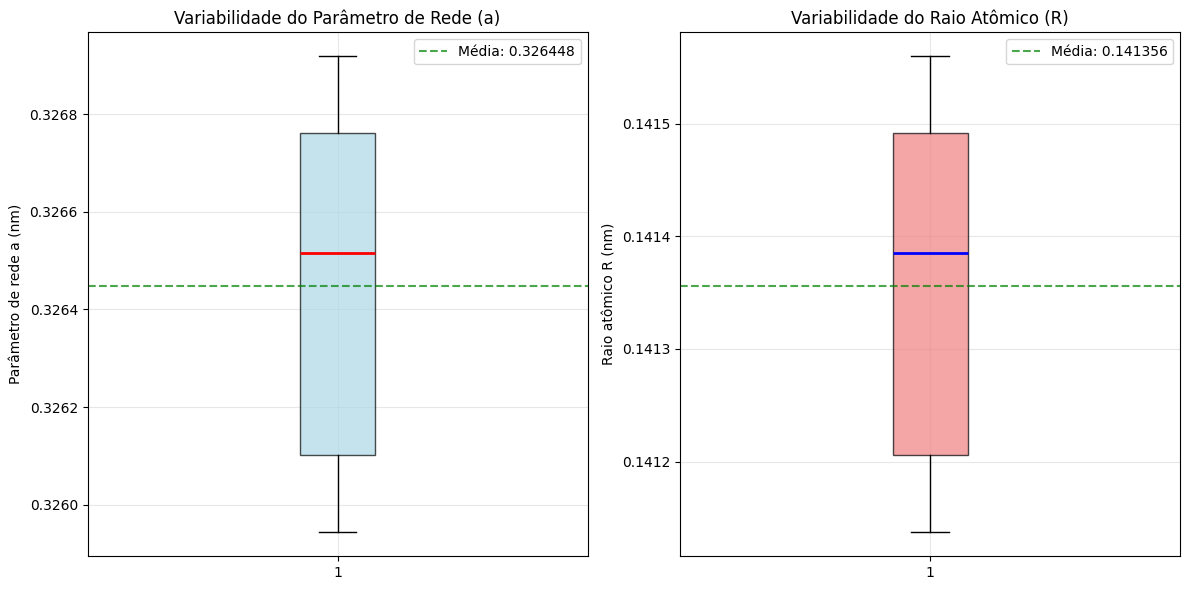

/tmp/ipython-input-482276499.py:76: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, positions=positions, patch_artist=True,


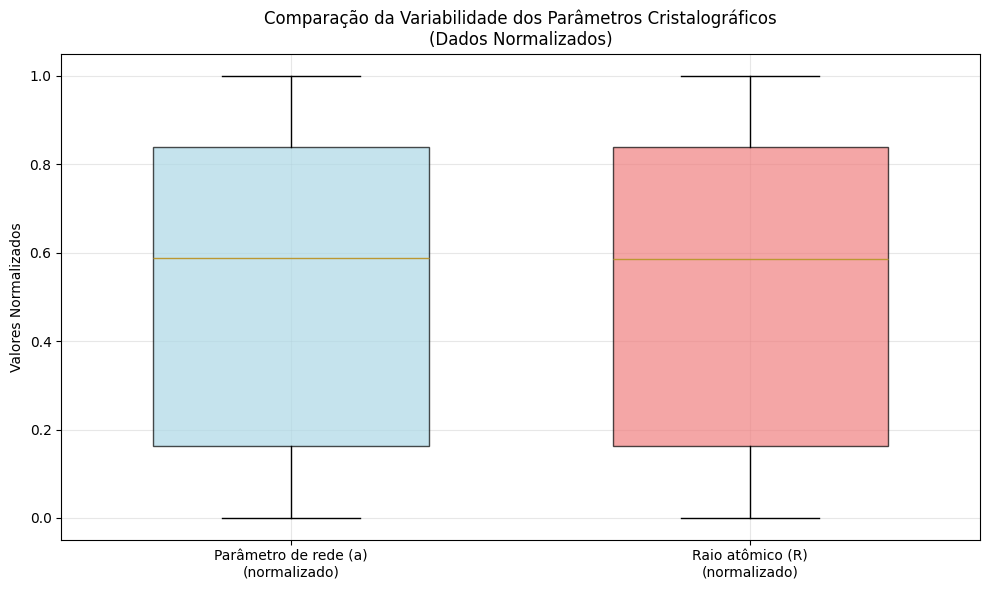

Resultados salvos em 'resultados_cristalograficos.txt'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configurar o estilo dos gráficos
plt.style.use('default')
sns.set_palette("husl")

def calcular_estatisticas(dados, nome_parametro):
    """
    Calcula média, desvio padrão e erro padrão para um conjunto de dados
    """
    media = np.mean(dados)
    desvio_padrao = np.std(dados, ddof=1)  # ddof=1 para amostra
    erro_padrao = desvio_padrao / np.sqrt(len(dados))

    print(f"\n{nome_parametro}:")
    print(f"  Média: {media:.6f}")
    print(f"  Desvio Padrão: {desvio_padrao:.6f}")
    print(f"  Erro Padrão: {erro_padrao:.6f}")

    return media, desvio_padrao, erro_padrao

def criar_graficos_boxplot(df):
    """
    Cria gráficos de caixa para visualizar a variabilidade dos dados
    """
    # Configurar a figura com subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # Gráfico de caixa para o parâmetro de rede (a)
    box1 = ax1.boxplot(df['a_nm'], patch_artist=True,
                       boxprops=dict(facecolor='lightblue', alpha=0.7),
                       medianprops=dict(color='red', linewidth=2))
    ax1.set_ylabel('Parâmetro de rede a (nm)')
    ax1.set_title('Variabilidade do Parâmetro de Rede (a)')
    ax1.grid(True, alpha=0.3)

    # Adicionar estatísticas no gráfico
    media_a = np.mean(df['a_nm'])
    ax1.axhline(y=media_a, color='green', linestyle='--', alpha=0.7, label=f'Média: {media_a:.6f}')
    ax1.legend()

    # Gráfico de caixa para o raio atômico (R)
    box2 = ax2.boxplot(df['R_nm'], patch_artist=True,
                       boxprops=dict(facecolor='lightcoral', alpha=0.7),
                       medianprops=dict(color='blue', linewidth=2))
    ax2.set_ylabel('Raio atômico R (nm)')
    ax2.set_title('Variabilidade do Raio Atômico (R)')
    ax2.grid(True, alpha=0.3)

    # Adicionar estatísticas no gráfico
    media_r = np.mean(df['R_nm'])
    ax2.axhline(y=media_r, color='green', linestyle='--', alpha=0.7, label=f'Média: {media_r:.6f}')
    ax2.legend()

    plt.tight_layout()
    plt.show()

def criar_grafico_combinado(df):
    """
    Cria um gráfico combinado mostrando ambos os parâmetros
    """
    fig, ax = plt.subplots(figsize=(10, 6))

    # Normalizar os dados para melhor visualização
    a_norm = (df['a_nm'] - df['a_nm'].min()) / (df['a_nm'].max() - df['a_nm'].min())
    r_norm = (df['R_nm'] - df['R_nm'].min()) / (df['R_nm'].max() - df['R_nm'].min())

    positions = [1, 2]
    data_to_plot = [a_norm, r_norm]
    labels = ['Parâmetro de rede (a)\n(normalizado)', 'Raio atômico (R)\n(normalizado)']

    bp = ax.boxplot(data_to_plot, positions=positions, patch_artist=True,
                    labels=labels, widths=0.6)

    # Colorir as caixas
    colors = ['lightblue', 'lightcoral']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.set_title('Comparação da Variabilidade dos Parâmetros Cristalográficos\n(Dados Normalizados)')
    ax.set_ylabel('Valores Normalizados')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def main():
    # Dados da tabela
    dados = {
        'Plano': ['101', '200', '211', '220', '310'],
        'h2_k2_l2': [2, 4, 6, 8, 10],
        'theta_2_graus': [39.140000, 56.520000, 70.720000, 83.940000, 96.620000],
        'sen_theta': [0.334958, 0.473473, 0.578712, 0.668741, 0.746754],
        'dhkl_nm': [0.230476, 0.163050, 0.133400, 0.115441, 0.103381],
        'a_nm': [0.325943, 0.326101, 0.326761, 0.326516, 0.326919],
        'R_nm': [0.141137, 0.141206, 0.141492, 0.141385, 0.141560]
    }

    # Criar DataFrame
    df = pd.DataFrame(dados)

    print("ANÁLISE ESTATÍSTICA DOS PARÂMETROS CRISTALOGRÁFICOS")
    print("=" * 60)

    # Exibir a tabela
    print("\nTabela de dados:")
    print(df.to_string(index=False))

    print("\n" + "=" * 60)
    print("RESULTADOS ESTATÍSTICOS")
    print("=" * 60)

    # Calcular estatísticas para o parâmetro de rede (a)
    media_a, desvio_a, erro_a = calcular_estatisticas(df['a_nm'], "PARÂMETRO DE REDE (a)")

    # Calcular estatísticas para o raio atômico (R)
    media_r, desvio_r, erro_r = calcular_estatisticas(df['R_nm'], "RAIO ATÔMICO (R)")

    # Informações adicionais
    print(f"\n" + "=" * 60)
    print("INFORMAÇÕES ADICIONAIS")
    print("=" * 60)
    print(f"Número de medições: {len(df)}")
    print(f"Coeficiente de variação (a): {(desvio_a/media_a)*100:.4f}%")
    print(f"Coeficiente de variação (R): {(desvio_r/media_r)*100:.4f}%")

    # Teste de normalidade (Shapiro-Wilk)
    stat_a, p_a = stats.shapiro(df['a_nm'])
    stat_r, p_r = stats.shapiro(df['R_nm'])

    print(f"\nTeste de Normalidade (Shapiro-Wilk):")
    print(f"  Parâmetro a - p-valor: {p_a:.6f}")
    print(f"  Raio R - p-valor: {p_r:.6f}")

    # Intervalo de confiança (95%)
    from scipy.stats import t
    n = len(df)
    t_value = t.ppf(0.975, n-1)  # 95% de confiança

    ic_a = (media_a - t_value * erro_a, media_a + t_value * erro_a)
    ic_r = (media_r - t_value * erro_r, media_r + t_value * erro_r)

    print(f"\nIntervalo de Confiança (95%):")
    print(f"  Parâmetro a: [{ic_a[0]:.6f}, {ic_a[1]:.6f}]")
    print(f"  Raio R: [{ic_r[0]:.6f}, {ic_r[1]:.6f}]")

    # Criar gráficos
    print(f"\n" + "=" * 60)
    print("GERANDO GRÁFICOS...")
    print("=" * 60)

    criar_graficos_boxplot(df)
    criar_grafico_combinado(df)

    # Salvar resultados em arquivo
    with open('resultados_cristalograficos.txt', 'w', encoding='utf-8') as f:
        f.write("ANÁLISE ESTATÍSTICA DOS PARÂMETROS CRISTALOGRÁFICOS\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"PARÂMETRO DE REDE (a):\n")
        f.write(f"  Média: {media_a:.6f} nm\n")
        f.write(f"  Desvio Padrão: {desvio_a:.6f} nm\n")
        f.write(f"  Erro Padrão: {erro_a:.6f} nm\n")
        f.write(f"  Intervalo de Confiança (95%): [{ic_a[0]:.6f}, {ic_a[1]:.6f}] nm\n\n")
        f.write(f"RAIO ATÔMICO (R):\n")
        f.write(f"  Média: {media_r:.6f} nm\n")
        f.write(f"  Desvio Padrão: {desvio_r:.6f} nm\n")
        f.write(f"  Erro Padrão: {erro_r:.6f} nm\n")
        f.write(f"  Intervalo de Confiança (95%): [{ic_r[0]:.6f}, {ic_r[1]:.6f}] nm\n")

    print("Resultados salvos em 'resultados_cristalograficos.txt'")

if __name__ == "__main__":
    main()


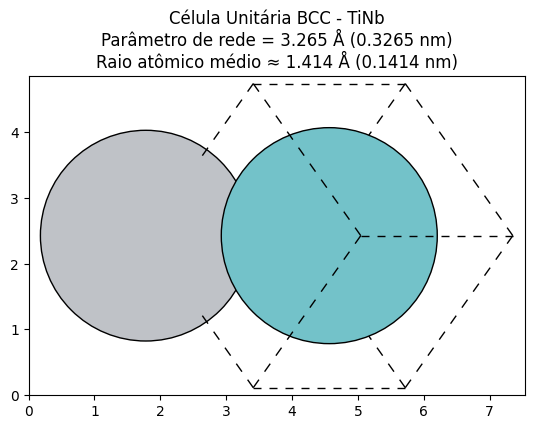

In [ ]:
# Instalar a biblioteca ASE
!pip install ase

# Importações
from ase import Atoms
from ase.visualize.plot import plot_atoms
from ase.visualize import view
import matplotlib.pyplot as plt
import random

# =======================
# Parâmetros físicos
# =======================

# Parâmetro de rede BCC (dado): 0.3265 nm = 3.265 Å
a = 3.265  # [Å] = 0.3265 nm

# Raio atômico médio informado: 0.1414 nm = 1.414 Å
raio_atomico = 1.414  # [Å]

# =======================
# Célula unitária BCC
# =======================

# Vetores da célula cúbica (BCC)
cell = [
    [a, 0, 0],  # vetor a
    [0, a, 0],  # vetor b
    [0, 0, a]   # vetor c
]

# Posições fracionárias dos 2 átomos na célula BCC
positions = [
    [0.0, 0.0, 0.0],     # canto
    [0.5, 0.5, 0.5]      # centro
]

# Elementos: 1 Ti e 1 Nb (exemplo próximo de proporção desejada)
# Se preferir outra combinação, troque os símbolos abaixo
symbols = ['Ti', 'Nb']

# Criação da estrutura
structure = Atoms(
    symbols=symbols,
    scaled_positions=positions,
    cell=cell,
    pbc=True
)

# =======================
# Visualização
# =======================

# Visualização 3D (pode não abrir no Colab)
view(structure)

# Visualização 2D (funciona no notebook)
plot_atoms(structure, rotation=('45x,45y,0z'), show_unit_cell=2)
plt.title(f'Célula Unitária BCC - TiNb\nParâmetro de rede = {a} Å (0.3265 nm)\nRaio atômico médio ≈ {raio_atomico} Å (0.1414 nm)')
plt.show()


In [ ]:
# Temperaturas de fusão em Kelvin
T_fusion = {
    'Ti': 1941,
    'Mo': 2896,
    'Nb': 2750
}

# Frações molares da liga Ti50Mo12Nb38
fractions = {
    'Ti': 0.50,
    'Mo': 0.12,
    'Nb': 0.38
}

# Estimativa usando média ponderada
T_alloy = sum(fractions[el] * T_fusion[el] for el in fractions)
print(f"Temperatura estimada de fusão da liga: {T_alloy:.2f} K")



Temperatura estimada de fusão da liga: 2363.02 K
